## 1. Environment Setup

### 1.1 Import Libraries

In [49]:
import pandas as pd
import numpy as np
import re
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from collections import OrderedDict


### 1.2 UTC Time Conversion

Telegram stores message timestamps in the **local time of the channel author** (Europe/Kyiv).
Kyiv is UTC+2 in winter and UTC+3 in summer (DST), so a naive conversion would
introduce a systematic offset when joining with Reddit or ISW data, which use UTC.

We define a helper `convert_to_utc()` that:
1. **Localizes** the naive datetime series to `Europe/Kyiv` (marking existing timestamps as Kyiv time).
2. **Converts** to UTC using `tz_convert('UTC')`, which correctly accounts for DST transitions.
3. **Strips** the tzinfo (`tz_localize(None)`) to return a naive UTC datetime compatible with the rest of the pipeline.

In [50]:
import pytz

KYIV_TZ = pytz.timezone('Europe/Kyiv')

def convert_to_utc(dt_series):
    """
    Convert a pandas datetime series from Kyiv local time to UTC.

    Steps:
    1. tz_localize('Europe/Kyiv') — mark timestamps as Kyiv local time.
       ambiguous='NaT' turns the ambiguous DST overlap hour into NaT instead of raising.
       nonexistent='shift_forward' handles the spring-forward gap.
    2. ffill() — fill the rare NaT slots from the previous valid value.
    3. tz_convert('UTC') — shift to UTC (accounts for +2 / +3 offset automatically).
    4. tz_localize(None) — strip tzinfo to keep naive UTC datetimes for the rest of
       the pipeline.
    """
    localized = dt_series.dt.tz_localize(
        KYIV_TZ,
        ambiguous='NaT',
        nonexistent='shift_forward'
    )
    localized = localized.ffill()
    return localized.dt.tz_convert('UTC').dt.tz_localize(None)

### 1.3 Data Loading

Telegram stores its export in JSON format. All messages are located under the `messages` key.
Each message contains a `type` field — we only care about entries with the value `message`
(the rest are service events: pinned posts, channel name changes, etc.).

In [51]:
json_path = 'result.json'

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df_raw = pd.DataFrame(data['messages'])

print(f"Total records in file: {len(df_raw)}")
print(f"Record types distribution:\n{df_raw['type'].value_counts()}")

Total records in file: 57579
Record types distribution:
type
message    57570
service        9
Name: count, dtype: int64


In [52]:
df_raw.head()

,id,type,date,date_unixtime,actor,actor_id,action,title,text,text_entities,...,media_type,mime_type,duration_seconds,file_name,forwarded_from,forwarded_from_id,message_id,inline_bot_buttons,reply_to_message_id,sticker_emoji
0,1,service,2019-02-11T19:55:59,1549907759,Повітряні Сили ЗС України / Air Force of the A...,channel1223955273,create_channel,Командування Повітряних Сил ЗСУ / Air Force Co...,,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,service,2019-02-12T23:05:22,1550005522,Повітряні Сили ЗС України / Air Force of the A...,channel1223955273,edit_group_photo,NaN,,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,message,2019-02-18T14:37:13,1550493433,NaN,NaN,NaN,NaN,"[Повік не забудемо подвиг Героїв, які віддали ...","[{'type': 'plain', 'text': 'Повік не забудемо ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,message,2019-02-18T16:45:11,1550501111,NaN,NaN,NaN,NaN,[Курсанти IV курсу льотного факультету Харківс...,"[{'type': 'plain', 'text': 'Курсанти IV курсу ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,message,2019-02-18T18:55:54,1550508954,NaN,NaN,NaN,NaN,"[{'type': 'hashtag', 'text': '#Пвк'}, «Схід»,...","[{'type': 'hashtag', 'text': '#Пвк'}, {'type':...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Preprocessing

### 2.1 Text Extraction and Date Parsing

The `text` field in Telegram exports can be either a plain string or a list of objects
(when the message contains hashtags, links, or mentions). Before writing the extraction
function, we inspect the raw structure to understand what we are working with.

In [53]:
df_raw['text_entities'].head(10)

0                                                   []
1                                                   []
2    [{'type': 'plain', 'text': 'Повік не забудемо ...
3    [{'type': 'plain', 'text': 'Курсанти IV курсу ...
4    [{'type': 'hashtag', 'text': '#Пвк'}, {'type':...
5    [{'type': 'hashtag', 'text': '#Дебальцевський_...
6    [{'type': 'link', 'text': 'https://www.faceboo...
7    [{'type': 'link', 'text': 'https://www.faceboo...
8    [{'type': 'link', 'text': 'https://www.faceboo...
9    [{'type': 'link', 'text': 'https://www.faceboo...
Name: text_entities, dtype: object

In [54]:
df_raw['text'].head(10)

0                                                     
1                                                     
2    [Повік не забудемо подвиг Героїв, які віддали ...
3    [Курсанти IV курсу льотного факультету Харківс...
4    [{'type': 'hashtag', 'text': '#Пвк'},  «Схід»,...
5    [{'type': 'hashtag', 'text': '#Дебальцевський_...
6    [{'type': 'link', 'text': 'https://www.faceboo...
7    [{'type': 'link', 'text': 'https://www.faceboo...
8    [{'type': 'link', 'text': 'https://www.faceboo...
9    [{'type': 'link', 'text': 'https://www.faceboo...
Name: text, dtype: object

We observed that the `text` and `text_entities` columns contain identical content. However, `text_entities` wraps even plain-text fragments in a redundant dictionary structure (`{'type': 'plain', 'text': '...'}`) alongside hyperlinks and hashtags. Since this structure adds no analytical value, we use only the `text` column going forward.

Beyond `date` and `text`, no other columns in the raw export carry useful signal for this analysis: `actor`, `action`, `title`, and media-related fields are either absent for the overwhelming majority of messages or pertain to service events that have already been filtered out. The pipeline therefore retains only these two columns for all downstream processing.

In [55]:
def get_clean_text(text_data):
    """Flatten Telegram's text field (string or list of dicts) into a plain string."""
    if isinstance(text_data, str):
        return text_data
    elif isinstance(text_data, list):
        return ''.join([
            item['text'] if isinstance(item, dict) else str(item)
            for item in text_data
        ])
    return ''

df_messages = df_raw[df_raw['type'] == 'message'].copy()
df_messages['text_raw'] = df_messages['text'].apply(get_clean_text)

df = df_messages[['date', 'text_raw']].copy()
df['date'] = pd.to_datetime(df['date'])
df['date'] = convert_to_utc(df['date'])  # Convert from Kyiv local time to UTC

print(f"Messages after filtering: {len(df)}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.head()

Messages after filtering: 57570
Date range: 2019-02-18 12:37:13 → 2026-03-14 01:38:04


,date,text_raw
2,2019-02-18 12:37:13,"Повік не забудемо подвиг Героїв, які віддали с..."
3,2019-02-18 14:45:11,Курсанти IV курсу льотного факультету Харківсь...
4,2019-02-18 16:55:54,"#Пвк «Схід», Всеукраїнський турнір пам’яті «Г..."
5,2019-02-18 17:09:37,#Дебальцевський_плацдарм\n\nДалі у відео...\n\...
6,2019-02-18 21:04:41,https://www.facebook.com/GeneralStaff.ua/video...


The `text` field in Telegram exports can be either a plain string or a list of objects
(when the message contains hashtags, links, or mentions). The `get_clean_text()` function
normalizes both cases into a single string.

After extracting raw text, we parse the `date` column and immediately convert it
from Kyiv local time to UTC using `convert_to_utc()`.

### 2.2 Filtering by the Date of Full-Scale Invasion

We keep only messages starting from February 24, 2022 — the date the full-scale invasion began.
Data before this date reflects a completely different context and would introduce noise into the model.

In [56]:
before = len(df)
df = df[df['date'] >= '2022-02-24'].copy()
df.reset_index(drop=True, inplace=True)

print(f"Removed messages before 24.02.2022: {before - len(df)}")
print(f"Messages remaining: {len(df)}")
df.head()

Removed messages before 24.02.2022: 47
Messages remaining: 57523


,date,text_raw
0,2022-02-24 21:17:22,ВАЖЛИВО ТА ТЕРМІНОВО! \n\nВ соцмережах та деяк...
1,2022-02-24 22:43:23,https://fb.watch/bnMUkUvwfp/
2,2022-02-24 22:43:47,ПОВІТРЯНІ СИЛИ ЗАВДАЛИ ВОРОГУ СУТТЄВИХ ВТРАТ\n...
3,2022-02-25 07:43:53,🛩🛩🛩🛩\nДо строю авіації Повітряних Сил Збройних...
4,2022-02-25 07:45:06,


### 2.3 Text Cleaning

Before extracting features, we apply uniform cleaning:
- convert to lowercase
- remove URLs and @mentions
- keep only Ukrainian/English letters, digits, and hyphens (hyphens matter for «міг-31»)
- remove stopwords and tokens shorter than 2 characters

The Ukrainian stopword dictionary is downloaded from a public repository. Additionally,
we remove channel-specific words that carry no analytical value.

In [57]:
url = 'https://raw.githubusercontent.com/skopytr/ukrainian-stopwords/master/ukrainian_stopwords.txt'
response = requests.get(url)
stopwords_ua = set(response.text.split('\n'))

custom_stopwords = {'підписатись', 'джерело', 'надіслати', 'канал', 'реклама', 'відео', 'фото'}
stopwords_ua.update(custom_stopwords)

def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+', '', text)
    # Keep Ukrainian and English letters, spaces, and hyphens
    text = re.sub(r'[^а-яіїєґa-z\s-]', ' ', text)
    words = text.split()
    # Filter out stopwords and single-character tokens
    words = [w for w in words if w not in stopwords_ua and len(w) > 1]
    return ' '.join(words)

df['text_clean'] = df['text_raw'].apply(clean_text)

empty_after_clean = (df['text_clean'] == '').sum()
print(f"Messages with empty text after cleaning: {empty_after_clean} ({empty_after_clean/len(df)*100:.1f}%)")

sample = df[df['text_clean'] != ''].iloc[0]
print(f"\nCleaned:  {sample['text_clean'][:120]}")
print(f"\nOriginal: {sample['text_raw'][:150]}")

Messages with empty text after cleaning: 624 (1.1%)

Cleaned:  важливо та терміново соцмережах та деяких змі поширюються фейки про те що треба вимкнути всі прилади та до нуля знизити 

Original: ВАЖЛИВО ТА ТЕРМІНОВО! 

В соцмережах та деяких ЗМІ поширюються ФЕЙКИ про те, що у 23.30 треба вимкнути всі прилади та до нуля знизити споживання в осе


## 3. Feature Engineering

### 3.1 City Dictionary

For consistency with weather and alarm datasets, we use the same set of 23 regional centers.
Regex patterns cover the main spelling variants of each city in Ukrainian.

Important detail: `\w*` after the root allows finding all inflected forms —
«київ», «києві», «київський», etc.

In [58]:
city_patterns = {
    'Cherkasy':        r'\b(?:черкас)\w*',
    'Chernihiv':       r'\b(?:чернігів|чернігов)\w*',
    'Chernivtsi':      r'\b(?:чернівц|буковин)\w*',
    'Dnipro':          r'\b(?:дніпр|дніпропетровськ)\w*',
    'Donetsk':         r'\b(?:донецьк|донець)\w*',
    'Ivano-Frankivsk': r'\b(?:франківськ|прикарпатт|коломи)\w*',
    'Kharkiv':         r'\b(?:харків|харков|чугуїв|купянськ)\w*',
    'Kherson':         r'\b(?:херсон|берислав)\w*',
    'Khmelnytskyi':    r'\b(?:хмельницьк|старокостянтинів|шепетівк)\w*',
    'Kropyvnytskyi':   r'\b(?:кропивницьк|кіровоград|олександрі)\w*',
    'Kyiv':            r'\b(?:київ|києва|васильків|білоцерків)\w*',
    'Lutsk':           r'\b(?:луцьк|ковель|волин)\w*',
    'Lviv':            r'\b(?:львів|стрий|дрогобич)\w*',
    'Mykolaiv':        r'\b(?:миколаїв|очаків|вознесенськ)\w*',
    'Odesa':           r'\b(?:одес|ізмаїл|чорноморськ)\w*',
    'Poltava':         r'\b(?:полтав|кременчу|миргород)\w*',
    'Rivne':           r'\b(?:рівн|дубн)\w*',
    'Sumy':            r'\b(?:сум|шостк|конотоп|охтирк)\w*',
    'Ternopil':        r'\b(?:тернопіль)\w*',
    'Uzhhorod':        r'\b(?:ужгород|мукачев|закарпат)\w*',
    'Vinnytsia':       r'\b(?:вінниц|жмеринк)\w*',
    'Zaporizhzhia':    r'\b(?:запоріж|мелітопол)\w*',
    'Zhytomyr':        r'\b(?:житомир|бердичів|коростен)\w*',
}

print(f"Cities in base dictionary: {len(city_patterns)}")

Cities in base dictionary: 23


### 3.2 Oblast Name Expansion

Many messages refer to regions using oblast-form names (e.g. «Донеччині», «Запорізьку», «Харківщина»)
rather than city names. Before expanding the dictionary, we check how many messages the base
`city_patterns` misses and what kind of content they are.

We display both the original and the cleaned text so we can verify nothing was lost in the transformation.

In [59]:
def _has_city_base(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    return any(re.search(p, text, re.IGNORECASE) for p in city_patterns.values())

no_city = df[~df['text_clean'].apply(_has_city_base)].copy()

print(f"Messages without a city: {len(no_city):,} of {len(df):,} ({len(no_city)/len(df)*100:.1f}%)")
print("\n" + "="*60)
sample = no_city[no_city['text_raw'].str.strip() != ''].sample(min(20, len(no_city)), random_state=42)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f"\n[{i}] {row['date'].strftime('%Y-%m-%d %H:%M')}")
    print(f"  Original: {row['text_raw'][:200]}")
    print(f"  Cleaned:  {row['text_clean'][:200]}")

Messages without a city: 20,876 of 57,523 (36.3%)


[1] 2025-09-10 12:13
  Original: 🚀Пуски керованих авіаційних бомб ворожою тактичною авіацією на Донеччині.
  Cleaned:  пуски керованих авіаційних бомб ворожою тактичною авіацією на донеччині

[2] 2025-11-09 15:34
  Original: 🚀 Пуски КАБ на Запорізьку область!
  Cleaned:  пуски каб на запорізьку область

[3] 2025-12-17 21:05
  Original: 🚀 Пуски КАБ на Запорізьку область.
  Cleaned:  пуски каб на запорізьку область

[4] 2024-03-04 09:19
  Original: 📢 Відбій по областях.
  Cleaned:  відбій по областях

[5] 2025-02-20 20:26
  Original: 🛵 Біла Церква ➡️ залишайтесь в укриттях! БпЛА ➡️ у передмісті.
  Cleaned:  біла церква залишайтесь укриттях бпла передмісті

[6] 2025-11-13 15:55
  Original: 🚀Пуски керованих авіаційних бомб ворожою тактичною авіацією на Донеччину.
  Cleaned:  пуски керованих авіаційних бомб ворожою тактичною авіацією на донеччину

[7] 2024-06-25 07:08
  Original: ⚠Увага!
☄️ Загроза застосування балістичного озброєння з пів

Some of these are genuinely nationwide messages without a specific city.
But there are also messages where the city is written as an oblast name (e.g. «Донеччині», «Запорізьку»).
So we check how many of these an expanded oblast dictionary would catch:

In [60]:
oblast_patterns = {
    'Kyiv':            r'\b(?:київщин|броварах|біла церква|бровари)\w*',
    'Kharkiv':         r'\b(?:харківщин)\w*',
    'Donetsk':         r'\b(?:донеччин)\w*',
    'Odesa':           r'\b(?:одещин)\w*',
    'Dnipro':          r'\b(?:дніпропетровщин)\w*',
    'Zaporizhzhia':    r'\b(?:запорізьк)\w*',
    'Mykolaiv':        r'\b(?:миколаївщин)\w*',
    'Kherson':         r'\b(?:херсонщин)\w*',
    'Poltava':         r'\b(?:полтавщин)\w*',
    'Sumy':            r'\b(?:сумщин)\w*',
    'Chernihiv':       r'\b(?:чернігівщин)\w*',
    'Lviv':            r'\b(?:львівщин)\w*',
    'Vinnytsia':       r'\b(?:вінниччин)\w*',
    'Zhytomyr':        r'\b(?:житомирщин)\w*',
    'Cherkasy':        r'\b(?:черкащин)\w*',
    'Rivne':           r'\b(?:рівненщин)\w*',
    'Lutsk':           r'\b(?:волинщин|волинськ)\w*',
    'Khmelnytskyi':    r'\b(?:хмельниччин)\w*',
    'Ternopil':        r'\b(?:тернопільщин)\w*',
    'Ivano-Frankivsk': r'\b(?:івано-франківщин|прикарпатськ)\w*',
    'Uzhhorod':        r'\b(?:закарпатськ)\w*',
    'Chernivtsi':      r'\b(?:чернівеччин)\w*',
    'Kropyvnytskyi':   r'\b(?:кіровоградщин)\w*',
}

caught = 0
for _, row in no_city.iterrows():
    for city, pattern in oblast_patterns.items():
        if re.search(pattern, row['text_clean'], re.IGNORECASE):
            caught += 1
            break

print(f"Additionally captured: {caught:,} of {len(no_city):,} no_city messages ({caught/len(no_city)*100:.1f}%)")

Additionally captured: 4,617 of 20,876 no_city messages (22.1%)


The result is significant. We merge `city_patterns` and `oblast_patterns` into a single
`city_patterns_full` dictionary, then verify what remains after expansion — whether the
unmatched messages are truly nationwide.

In [61]:
city_patterns_full = {}
for city in city_patterns:
    base   = re.search(r'\(\?:(.+?)\)\\w', city_patterns[city])
    oblast = re.search(r'\(\?:(.+?)\)\\w', oblast_patterns.get(city, ''))
    parts  = []
    if base:   parts.append(base.group(1))
    if oblast: parts.append(oblast.group(1))
    city_patterns_full[city] = r'\b(?:' + '|'.join(parts) + r')\w*'

print(f"Cities in expanded dictionary: {len(city_patterns_full)}")
print(f"\nPattern merge check:")
print(f"  Kyiv:    {city_patterns_full['Kyiv']}")
print(f"  Donetsk: {city_patterns_full['Donetsk']}")

test_cases = [('київщина','Kyiv'),('донеччині','Donetsk'),('бровари','Kyiv'),('києва','Kyiv')]
print("\nRecognition check:")
for text, city in test_cases:
    found = bool(re.search(city_patterns_full[city], text, re.IGNORECASE))
    print(f"  '{text}' → {city}: {'✓' if found else '✗'}")

Cities in expanded dictionary: 23

Pattern merge check:
  Kyiv:    \b(?:київ|києва|васильків|білоцерків|київщин|броварах|біла церква|бровари)\w*
  Donetsk: \b(?:донецьк|донець|донеччин)\w*

Recognition check:
  'київщина' → Kyiv: ✓
  'донеччині' → Donetsk: ✓
  'бровари' → Kyiv: ✓
  'києва' → Kyiv: ✓


In [62]:
def _has_city_full(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    return any(re.search(p, text, re.IGNORECASE) for p in city_patterns_full.values())

no_city = df[~df['text_clean'].apply(_has_city_full)].copy()

print(f"Messages without a city after expansion: {len(no_city):,} of {len(df):,} ({len(no_city)/len(df)*100:.1f}%)")
print("\n" + "="*60)
sample = no_city[no_city['text_raw'].str.strip() != ''].sample(min(10, len(no_city)), random_state=42)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f"\n[{i}] {row['date'].strftime('%Y-%m-%d %H:%M')}")
    print(f"  Original: {row['text_raw'][:200]}")
    print(f"  Cleaned:  {row['text_clean'][:200]}")

Messages without a city after expansion: 16,259 of 57,523 (28.3%)


[1] 2023-08-29 02:23
  Original: 📢 Відбій загрози.
  Cleaned:  відбій загрози

[2] 2022-03-05 09:14
  Original: ❗❗❗У Маріуполі та Волновасі готують гуманітарні коридори

Про це повідомив радник голови Офісу Президента Михайло Подоляк.

🔻 У Маріуполі визначають точний час, коли відкриється гуманітарний «зелений»
  Cleaned:  маріуполі та волновасі готують гуманітарні коридори про це повідомив радник голови офісу президента михайло подоляк маріуполі визначають точний час коли відкриється гуманітарний зелений коридор та поч

[3] 2023-07-18 20:01
  Original: ⚠️ Увага!
Зафіксовано запуск ударних БпЛА типу "Shahed" з південного напрямку.
Орієнтовний час оголошення повітряної тривоги в південних  областях близько опівночі.
У разі загрози ударних БпЛА повідом
  Cleaned:  увага зафіксовано запуск ударних бпла типу shahed південного напрямку орієнтовний час оголошення повітряної тривоги південних областях близько опівночі разі за

These are genuinely nationwide messages — directional threats without a specific location.
The expanded dictionary reduced unmatched messages from ~36% to ~28%, capturing an additional ~4,600 messages.

### 3.3 City Extraction and Row Duplication

**Idea:** if a single message mentions multiple cities, we do not join them into a comma-separated string —
instead we duplicate the row for each city. This creates a `city` column that allows:
- aggregating threats *separately for each city*
- building a model where city is a full dimension, not just a text label

**Handling nationwide messages:** if no city is found — the message is duplicated for *all* 23 cities.
The logic: «threat from the northern direction» or «aviation activity for frontline oblasts» is a signal for
every city, just without a specific geolocation.

In [63]:
all_cities = list(city_patterns_full.keys())

def extract_cities(text):
    """Return a list of cities mentioned in the text.
    If no city is found — return all cities
    (nationwide message → duplicate for each city)."""
    if not isinstance(text, str) or text.strip() == '':
        return all_cities
    found = [
        city for city, pattern in city_patterns_full.items()
        if re.search(pattern, text, re.IGNORECASE)
    ]
    return found if found else all_cities

df['cities'] = df['text_clean'].apply(extract_cities)

with_city    = df['cities'].apply(lambda x: len(x) < len(all_cities)).sum()
without_city = df['cities'].apply(lambda x: len(x) == len(all_cities)).sum()
print(f"Messages with a specific city:           {with_city:,} ({with_city/len(df)*100:.1f}%)")
print(f"Nationwide (duplicated for all cities):  {without_city:,} ({without_city/len(df)*100:.1f}%)")

df_exploded = df.explode('cities').rename(columns={'cities': 'city'})
df_exploded.reset_index(drop=True, inplace=True)

print(f"\nRows before duplication: {len(df):,}")
print(f"Rows after duplication:  {len(df_exploded):,}")
print(f"\nCity distribution (top-10):")
print(df_exploded['city'].value_counts().head(10))

Messages with a specific city:           41,264 (71.7%)
Nationwide (duplicated for all cities):  16,259 (28.3%)

Rows before duplication: 57,523
Rows after duplication:  445,648

City distribution (top-10):
city
Sumy            26066
Kharkiv         24763
Dnipro          23010
Chernihiv       22021
Poltava         21466
Donetsk         21396
Zaporizhzhia    21344
Kyiv            20918
Mykolaiv        19911
Odesa           19469
Name: count, dtype: int64


### 3.4 Threat Dictionary

We start with a base dictionary and check how many messages with a city are not captured —
expanding each time until coverage is acceptable.

In [65]:
threat_dict = {
    'tg_shaheds':      ['шахед', 'герань', 'мопед', 'бпла', 'безпілотник', 'дрон', 'камікадзе'],
    'tg_ballistic':    ['балістик', 'балістичн', 'іскандер', 'с-300', 'с-400', 'оперативно-тактичн'],
    'tg_mig31':        ['міг-31', 'кинджал', 'саваслейка', 'моздок', 'аеробалістич'],
    'tg_cruise':       ['крилат', 'калібр', 'х-101', 'х-555', 'ту-95', 'ту-22', 'ракет'],
    'tg_guided_bombs': ['каби', 'су-34', 'су-35', 'авіабомб', 'планеруюч'],
    'tg_artillery':    ['артилері', 'рсзв', 'смерч', 'мінометн'],
}

def count_threat(text, keywords):
    """Return 1 if at least one keyword is found in the text, otherwise 0."""
    if not isinstance(text, str) or text.strip() == '':
        return 0
    return int(any(kw in text for kw in keywords))

threat_cols = list(threat_dict.keys())

for col, keywords in threat_dict.items():
    df_exploded[col] = df_exploded['text_clean'].apply(lambda t: count_threat(t, keywords))

print("Total messages per threat type:")
print(df_exploded[threat_cols].sum().sort_values(ascending=False))

Total messages per threat type:
tg_shaheds         93578
tg_ballistic       88694
tg_cruise          56263
tg_mig31            5471
tg_artillery        2638
tg_guided_bombs     2230
dtype: int64


Now we need to check whether there are messages with a city but no threat of any kind.

In [66]:
# Look at messages WHERE a city is present but NO threat is found
threat_keywords_flat = [kw for keywords in threat_dict.values() for kw in keywords]

def has_threat(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    return any(kw in text for kw in threat_keywords_flat)

def has_city(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    return any(re.search(p, text, re.IGNORECASE) for p in city_patterns_full.values())

city_no_threat = df[df['text_clean'].apply(has_city) & ~df['text_clean'].apply(has_threat)].copy()

print(f"Messages with a city but no threat: {len(city_no_threat):,} of {len(df):,} ({len(city_no_threat)/len(df)*100:.1f}%)")
print("="*60)
sample = city_no_threat[city_no_threat['text_raw'].str.strip() != ''].sample(min(20, len(city_no_threat)), random_state=42)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f"\n[{i}] {row['date'].strftime('%Y-%m-%d %H:%M')}")
    print(f"  Original: {row['text_raw'][:200]}")
    print(f"  Cleaned:  {row['text_clean'][:200]}")

Messages with a city but no threat: 11,266 of 57,523 (19.6%)

[1] 2024-11-07 18:55
  Original: 🚀Пуски керованих авіаційних бомб тактичною авіацією на Сумщину.
  Cleaned:  пуски керованих авіаційних бомб тактичною авіацією на сумщину

[2] 2024-08-26 06:18
  Original: 2 КР на Вінниччині у північно-західному напрямку!
  Cleaned:  кр на вінниччині північно-західному напрямку

[3] 2024-12-12 07:45
  Original: 🚀Повторні пуски керованих авіаційних бомб ворожою тактичною авіацією на Донеччину.
  Cleaned:  повторні пуски керованих авіаційних бомб ворожою тактичною авіацією на донеччину

[4] 2025-04-03 12:10
  Original: 🚀Пуски керованих авіаційних бомб ворожою тактичною авіацією на межі Харківщини і Донеччини..
  Cleaned:  пуски керованих авіаційних бомб ворожою тактичною авіацією на межі харківщини донеччини

[5] 2025-05-28 12:13
  Original: 🚀Пуски КАБ ворожою тактичною авіацією на Сумщині.
  Cleaned:  пуски каб ворожою тактичною авіацією на сумщині

[6] 2025-10-09 14:51
  Original: КАБ повз за

These are not noise — they are real threats, but the dictionary simply doesn't catch them.
Therefore we should not filter these out — instead, we need to expand `threat_dict`.

Inspecting the unmatched messages reveals several distinct groups of missed threats:

-  [4], [9], [12], [14], [20] — guided bombs: phrases 'пуски керованих', 'авіаційних бомб' are present in text_clean but absent from the dictionary
-  [2], [6] — aviation threats: 'тактичної авіації', 'авіаційних засобів ураження'
-  [5], [10], [13], [16], [19] — ballistic: 'швидкісна', 'швидкісні' (after cleaning, «швидкісна на київ» → 'швидкісна' — the preposition is stripped)
- [1], [3], [7] — generic shelter alerts: 'укриттях', 'укриття', 'перебувайте'
- [17] — CR abbreviation: 'кр' survives cleaning as a standalone token — see limitation note below
- [15] — target movement: 'продовжив'

In [69]:
threat_dict = {
    'tg_shaheds': [
        'шахед', 'герань', 'мопед', 'бпла', 'безпілотник', 'дрон', 'камікадзе',
        'тип shahed', 'shahed', 'типу shahed',
    ],
    'tg_ballistic': [
        'балістик', 'балістичн', 'іскандер', 'с-300', 'с-400', 'оперативно-тактичн',
        'швидкісна', 'швидкісні',
    ],
    'tg_mig31': [
        'міг-31', 'кинджал', 'саваслейка', 'моздок', 'аеробалістич',
    ],
    'tg_cruise': [
        'крилат', 'калібр', 'х-101', 'х-555', 'ту-95', 'ту-22', 'ракет',
        'х-59', 'х-22', 'х-47',
    ],
    'tg_guided_bombs': [
        'каб', 'каби', 'су-34', 'су-35', 'авіабомб', 'планеруюч',
        'керованих авіаційних бомб',
        'керовані авіаційні бомби',
    ],
    'tg_artillery': [
        'артилері', 'рсзв', 'смерч', 'мінометн',
    ],
    'tg_all_clear': [
        'відбій',
    ],
    'tg_unknown_threat': [
        'укриття', 'перебувайте', 'залишайтесь', 'терміново',
        'змінила', 'змінив', 'змінили',
        'зміна курсу',
        'продовжив', 'рухаються', 'рухається',
        'група ворожих', 'нові групи',
        'напрямку', 'зайдуть', 'ціль',
        'залітають', 'далі', 'загроза',
        'авіаційних засобів ураження',
        'авіаційного озброєння',
        'тактичної авіації',      # може бути і КАБи і ракети
        'активністю ворожої',
        'пуски керованих',
        'курсом', 'продовжують рух', 'продовжує рух',
],
}

known_cols = ['tg_shaheds', 'tg_ballistic', 'tg_mig31',
              'tg_cruise', 'tg_guided_bombs', 'tg_artillery']

for col in known_cols + ['tg_all_clear']:
    df_exploded[col] = df_exploded['text_clean'].apply(
        lambda t: count_threat(t, threat_dict[col])
    )

# unknown only if no known threat matched
df_exploded['tg_unknown_threat'] = df_exploded['text_clean'].apply(
    lambda t: count_threat(t, threat_dict['tg_unknown_threat'])
)
df_exploded.loc[df_exploded[known_cols].sum(axis=1) > 0, 'tg_unknown_threat'] = 0

print("Total messages per threat type:")
print(df_exploded[threat_cols].sum().sort_values(ascending=False))

Total messages per threat type:
tg_shaheds         93666
tg_ballistic       93283
tg_cruise          56263
tg_guided_bombs    10750
tg_mig31            5471
tg_artillery        2615
dtype: int64


> **Note on 'КР' (cruise missile abbreviation).** Message [17] (`'кр курс сумщини на полтавщину'`) shows that after cleaning, `'кр'` survives as a standalone token in `text_clean`. However, adding `'кр'` as a plain substring keyword is not feasible due to the high false-positive rate: it is a substring of unrelated words such as «країна» (*country*), «кропивницьк» (*Kropyvnytskyi*), and «крило» (*wing*). The vast majority of cruise missile alerts are already caught via `'ракет'` and `'крилат'`, the marginal gain does not justify the added pipeline complexity. This represents an accepted minor coverage gap.

And checking again: 

In [70]:
threat_keywords_flat = [kw for keywords in threat_dict.values() for kw in keywords]

def has_threat(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    return any(kw in text for kw in threat_keywords_flat)

def has_city(text):
    if not isinstance(text, str) or text.strip() == '':
        return False
    return any(re.search(p, text, re.IGNORECASE) for p in city_patterns_full.values())

city_no_threat = df[df['text_clean'].apply(has_city) & ~df['text_clean'].apply(has_threat)].copy()

print(f"Messages with a city but no threat: {len(city_no_threat):,} of {len(df):,} ({len(city_no_threat)/len(df)*100:.1f}%)")
print("="*60)
sample = city_no_threat[city_no_threat['text_raw'].str.strip() != ''].sample(min(20, len(city_no_threat)), random_state=42)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f"\n[{i}] {row['date'].strftime('%Y-%m-%d %H:%M')}")
    print(f"  Original: {row['text_raw'][:200]}")
    print(f"  Cleaned:  {row['text_clean'][:200]}")

Messages with a city but no threat: 872 of 57,523 (1.5%)

[1] 2025-11-24 23:02
  Original: Група КР на півдні Кіровоградщини курс північний.
  Cleaned:  група кр на півдні кіровоградщини курс північний

[2] 2024-01-13 04:58
  Original: Напрямок Дніпро!
  Cleaned:  напрямок дніпро

[3] 2024-03-24 03:24
  Original: КР з Волині на Львівщину!
  Cleaned:  кр волині на львівщину

[4] 2025-10-13 10:25
  Original: 📹 На відео – бойова робота захисників неба у ніч на 13 жовтня 2025 року на Одещині у зоні відповідальності Повітряного командування "Південь".

🇺🇦 Продовжуємо нашу боротьбу!
  Cleaned:  на бойова робота захисників неба ніч на жовтня року на одещині зоні відповідальності повітряного командування південь продовжуємо нашу боротьбу

[5] 2024-05-21 00:31
  Original: 1. Залишки 🛵 на Одещині.

2. Група 🛵 у Кіровоградській області.
  Cleaned:  залишки на одещині група кіровоградській області

[6] 2024-01-18 02:08
  Original: +  Сумська, Полтавська.
  Cleaned:  сумська полтавська

[7] 2025-12

After few iterations of dictionary expansion, coverage stabilised at **1.4% unmatched** (805 of 57,523 messages). Manual inspection of the residual sample confirms that this remainder is structurally irreducible and falls into three categories: 

- (a) messages containing only the `'КР'` abbreviation, where safe keyword matching is not feasible without unacceptable false positives (discussed in the limitation note above);
- (b) messages reduced to a bare city name or preposition after stopword removal, with no recoverable threat signal (e.g. «Херсон!», «На Кропивницький», «на Полтавщину»);
- (c) general news, military announcements, and casualty summaries unrelated to air threat alerts.

All three subgroups are going to be dropped as noise, retaining **98.6% of all messages** for machine learning.


### 3.5 Filtering Messages With No Threat

What remains:
- messages with any threat (including `tg_unknown_threat`)
- nationwide messages without a specific city — they carry a general temporal signal

In [71]:
df['has_threat'] = df['text_clean'].apply(has_threat)
df['has_city']   = df['text_clean'].apply(has_city)

mask_keep = df['has_threat'] | ~df['has_city']
removed   = (~mask_keep).sum()

print(f"Removed (city present, no threat): {removed:,} ({removed/len(df)*100:.1f}%)")
print(f"Messages remaining: {mask_keep.sum():,}")

df_filtered = df[mask_keep].copy()
df_exploded = df_filtered.explode('cities').rename(columns={'cities': 'city'})
df_exploded.reset_index(drop=True, inplace=True)

Removed (city present, no threat): 872 (1.5%)
Messages remaining: 56,651


### 3.6 Additional Aggregating Features

One additional field reflecting overall message intensity:

- `tg_threat_type_count` — the number of distinct known weapon types mentioned in a single message.
  Counts only specific weapon categories: shaheds, ballistic, mig31, cruise, guided bombs, artillery.
  `tg_all_clear` and `tg_unknown_threat` are excluded — the former is the opposite of a threat,
  the latter represents an unidentified threat with no weapon type information.

If one message mentions both shaheds and ballistic missiles — `tg_threat_type_count = 2`,
  which is a strong signal of a combined mass strike.
  At the hourly level this is aggregated as `tg_threat_type_count_max` — the maximum value
  across all messages in a given (hour, city) slot.

**Proximity weapon correction.** Artillery and guided bombs are short-range weapons that cannot realistically threaten cities far from the front line. Artillery operates within ~40 km of the front, and guided bombs require aircraft to approach within 70–80 km of the target — meaning neither weapon can reach central or western Ukrainian cities under current conditions.

However, nationwide messages — broadcast to all 23 cities when no specific city is mentioned — frequently reference artillery or guided bombs in a general front-line context. Without correction, this inflates their counts for cities that were never actually targeted by these weapons.

To address this, `tg_artillery` and `tg_guided_bombs` are zeroed out for all rows originating from nationwide messages (identified as duplicate `date + text_clean` pairs across cities). Long-range weapons — shaheds, ballistic missiles, cruise missiles, and Kinzhal — are unaffected, as a nationwide alert for these weapons genuinely implies risk for all cities.

In [72]:
known_cols = ['tg_shaheds', 'tg_ballistic', 'tg_mig31',
              'tg_cruise', 'tg_guided_bombs', 'tg_artillery']

for col in known_cols + ['tg_all_clear']:
    df_exploded[col] = df_exploded['text_clean'].apply(
        lambda t: count_threat(t, threat_dict[col])
    )
df_exploded['tg_unknown_threat'] = df_exploded['text_clean'].apply(
    lambda t: count_threat(t, threat_dict['tg_unknown_threat'])
)
df_exploded.loc[df_exploded[known_cols].sum(axis=1) > 0, 'tg_unknown_threat'] = 0

In [73]:
# Zero out proximity weapons for truly nationwide messages (broadcast to all 23 cities)
nationwide_mask = df_exploded.duplicated(subset=['date', 'text_clean'], keep=False) & \
                  df_exploded.groupby(['date', 'text_clean'])['city'].transform('count').eq(len(all_cities))
df_exploded.loc[nationwide_mask, ['tg_artillery', 'tg_guided_bombs']] = 0
print(f"Nationwide rows zeroed: {nationwide_mask.sum():,}")
print(f"Artillery remaining:    {df_exploded['tg_artillery'].sum():,}")
print(f"Guided bombs remaining: {df_exploded['tg_guided_bombs'].sum():,}")

Nationwide rows zeroed: 363,768
Artillery remaining:    1,764
Guided bombs remaining: 8,818


In [74]:
df_exploded['tg_threat_type_count'] = df_exploded[known_cols + ['tg_unknown_threat']].sum(axis=1)

print(f"\nRows in df_exploded after filtering: {len(df_exploded):,}")
print("Distribution of threat type count per message:")
print(df_exploded['tg_threat_type_count'].value_counts().sort_index())


Rows in df_exploded after filtering: 444,495
Distribution of threat type count per message:
tg_threat_type_count
0     95715
1    328624
2     14703
3      4356
4      1095
5         2
Name: count, dtype: int64


## 4. Hourly Aggregation

### 4.1 Time Slot Rounding and Aggregation by `hour_slot + city`

We reduce individual messages to hourly slots, aggregating by **two keys**: `hour_slot` and `city`.

For each (hour, city) combination we compute:
- `tg_msg_count` — message count (main signal of channel activity)
- `tg_{threat}_count` — sum per threat type (how many messages in that hour mentioned this threat for this city)
- `tg_any_threat_ratio` — share of messages in that hour that mention any threat
- `tg_threat_diversity_max` — maximum number of threat types in a single message per hour (detects mass strikes)

In [75]:
df_exploded['hour_slot'] = df_exploded['date'].dt.floor('h')

all_threat_cols = known_cols + ['tg_all_clear', 'tg_unknown_threat']
agg_dict = {'text_clean': 'count'}
for col in all_threat_cols:
    agg_dict[col] = 'sum'
agg_dict['tg_threat_type_count'] = 'max'

hourly = df_exploded.groupby(['hour_slot', 'city']).agg(agg_dict).reset_index()

hourly.rename(columns={
    'text_clean':          'tg_msg_count',
    'tg_threat_type_count': 'tg_threat_type_count_max',
}, inplace=True)
hourly.rename(columns={col: f'{col}_count' for col in all_threat_cols}, inplace=True)

print(f"Hourly dataset shape: {hourly.shape}")
print(f"Unique hour_slots: {hourly['hour_slot'].nunique():,}")
print(f"Unique cities: {hourly['city'].nunique()}")
print(f"\nDate range: {hourly['hour_slot'].min()} → {hourly['hour_slot'].max()}")
hourly.head(10)

Hourly dataset shape: (280195, 12)
Unique hour_slots: 19,428
Unique cities: 23

Date range: 2022-02-24 21:00:00 → 2026-03-14 01:00:00


,hour_slot,city,tg_msg_count,tg_shaheds_count,tg_ballistic_count,tg_mig31_count,tg_cruise_count,tg_guided_bombs_count,tg_artillery_count,tg_all_clear_count,tg_unknown_threat_count,tg_threat_type_count_max
0,2022-02-24 21:00:00,Cherkasy,1,0,0,0,0,0,0,0,1,1
1,2022-02-24 21:00:00,Chernihiv,1,0,0,0,0,0,0,0,1,1
2,2022-02-24 21:00:00,Chernivtsi,1,0,0,0,0,0,0,0,1,1
3,2022-02-24 21:00:00,Dnipro,1,0,0,0,0,0,0,0,1,1
4,2022-02-24 21:00:00,Donetsk,1,0,0,0,0,0,0,0,1,1
5,2022-02-24 21:00:00,Ivano-Frankivsk,1,0,0,0,0,0,0,0,1,1
6,2022-02-24 21:00:00,Kharkiv,1,0,0,0,0,0,0,0,1,1
7,2022-02-24 21:00:00,Kherson,1,0,0,0,0,0,0,0,1,1
8,2022-02-24 21:00:00,Khmelnytskyi,1,0,0,0,0,0,0,0,1,1
9,2022-02-24 21:00:00,Kropyvnytskyi,1,0,0,0,0,0,0,0,1,1


### 4.2 Filtering Empty Slots

We keep only `(hour_slot, city)` combinations where real messages existed.

In [76]:
hourly = hourly[hourly['tg_msg_count'] > 0].reset_index(drop=True)

print(f"Rows after filtering: {len(hourly):,}")
print(f"Unique hour_slots: {hourly['hour_slot'].nunique():,}")
print(f"Unique cities: {hourly['city'].nunique()}")
hourly.head(10)

Rows after filtering: 280,195
Unique hour_slots: 19,428
Unique cities: 23


,hour_slot,city,tg_msg_count,tg_shaheds_count,tg_ballistic_count,tg_mig31_count,tg_cruise_count,tg_guided_bombs_count,tg_artillery_count,tg_all_clear_count,tg_unknown_threat_count,tg_threat_type_count_max
0,2022-02-24 21:00:00,Cherkasy,1,0,0,0,0,0,0,0,1,1
1,2022-02-24 21:00:00,Chernihiv,1,0,0,0,0,0,0,0,1,1
2,2022-02-24 21:00:00,Chernivtsi,1,0,0,0,0,0,0,0,1,1
3,2022-02-24 21:00:00,Dnipro,1,0,0,0,0,0,0,0,1,1
4,2022-02-24 21:00:00,Donetsk,1,0,0,0,0,0,0,0,1,1
5,2022-02-24 21:00:00,Ivano-Frankivsk,1,0,0,0,0,0,0,0,1,1
6,2022-02-24 21:00:00,Kharkiv,1,0,0,0,0,0,0,0,1,1
7,2022-02-24 21:00:00,Kherson,1,0,0,0,0,0,0,0,1,1
8,2022-02-24 21:00:00,Khmelnytskyi,1,0,0,0,0,0,0,0,1,1
9,2022-02-24 21:00:00,Kropyvnytskyi,1,0,0,0,0,0,0,0,1,1


### 4.3 Threat Ratio Feature

`tg_any_threat_ratio` = share of messages in a given (hour, city) slot that mention any threat.
A value of 1.0 means every message in that hour was a threat alert; 0.0 means none were.
This normalizes for channel activity volume and is useful as a standalone model feature.

In [77]:
threat_count_cols = [f'{col}_count' for col in threat_cols]

df_exploded['tg_any_threat'] = (df_exploded[threat_cols].sum(axis=1) > 0).astype(int)

threat_signal_cols = [
    'tg_shaheds_count', 'tg_ballistic_count', 'tg_mig31_count',
    'tg_cruise_count', 'tg_guided_bombs_count', 'tg_artillery_count',
    'tg_unknown_threat_count'
]
hourly['tg_any_threat_ratio'] = (
    (hourly[threat_signal_cols].sum(axis=1) > 0).astype(int)
    / hourly['tg_msg_count'].replace(0, 1)
)
print("tg_any_threat_ratio stats:")
print(hourly['tg_any_threat_ratio'].describe().round(3))
hourly.head()

tg_any_threat_ratio stats:
count    280195.000
mean          0.647
std           0.381
min           0.000
25%           0.333
50%           0.500
75%           1.000
max           1.000
Name: tg_any_threat_ratio, dtype: float64


,hour_slot,city,tg_msg_count,tg_shaheds_count,tg_ballistic_count,tg_mig31_count,tg_cruise_count,tg_guided_bombs_count,tg_artillery_count,tg_all_clear_count,tg_unknown_threat_count,tg_threat_type_count_max,tg_any_threat_ratio
0,2022-02-24 21:00:00,Cherkasy,1,0,0,0,0,0,0,0,1,1,1.0
1,2022-02-24 21:00:00,Chernihiv,1,0,0,0,0,0,0,0,1,1,1.0
2,2022-02-24 21:00:00,Chernivtsi,1,0,0,0,0,0,0,0,1,1,1.0
3,2022-02-24 21:00:00,Dnipro,1,0,0,0,0,0,0,0,1,1,1.0
4,2022-02-24 21:00:00,Donetsk,1,0,0,0,0,0,0,0,1,1,1.0


Some of slots have ratio = 0 — these are slots filled entirely by nationwide duplicates of news posts, casualty summaries, and announcements that passed the per-message filter but contain zero threat signal at the aggregated level.

These slots add noise without value — we drop them.

In [78]:
before = len(hourly)

hourly = hourly[hourly['tg_any_threat_ratio'] > 0].reset_index(drop=True)

print(f"Rows removed (zero threat ratio): {before - len(hourly):,} ({(before - len(hourly))/before*100:.1f}%)")
print(f"Rows remaining: {len(hourly):,}")
print(f"\ntg_any_threat_ratio stats after filtering:")
print(hourly['tg_any_threat_ratio'].describe().round(3))

Rows removed (zero threat ratio): 42,211 (15.1%)
Rows remaining: 237,984

tg_any_threat_ratio stats after filtering:
count    237984.000
mean          0.762
std           0.288
min           0.053
25%           0.500
50%           1.000
75%           1.000
max           1.000
Name: tg_any_threat_ratio, dtype: float64


In [79]:
hourly.head()

,hour_slot,city,tg_msg_count,tg_shaheds_count,tg_ballistic_count,tg_mig31_count,tg_cruise_count,tg_guided_bombs_count,tg_artillery_count,tg_all_clear_count,tg_unknown_threat_count,tg_threat_type_count_max,tg_any_threat_ratio
0,2022-02-24 21:00:00,Cherkasy,1,0,0,0,0,0,0,0,1,1,1.0
1,2022-02-24 21:00:00,Chernihiv,1,0,0,0,0,0,0,0,1,1,1.0
2,2022-02-24 21:00:00,Chernivtsi,1,0,0,0,0,0,0,0,1,1,1.0
3,2022-02-24 21:00:00,Dnipro,1,0,0,0,0,0,0,0,1,1,1.0
4,2022-02-24 21:00:00,Donetsk,1,0,0,0,0,0,0,0,1,1,1.0


Now we can delete this column, we won't need it anymore:

In [80]:
hourly.drop(columns=['tg_any_threat_ratio'], errors='ignore', inplace=True)

print(hourly.columns.tolist())

['hour_slot', 'city', 'tg_msg_count', 'tg_shaheds_count', 'tg_ballistic_count', 'tg_mig31_count', 'tg_cruise_count', 'tg_guided_bombs_count', 'tg_artillery_count', 'tg_all_clear_count', 'tg_unknown_threat_count', 'tg_threat_type_count_max']


## Summary 

The Telegram data has been transformed from raw JSON into a structured hourly feature matrix.

The pipeline covered four stages:

**Loading and cleaning** — service records filtered out, text collected from nested Telegram structures,
URLs, stopwords, and technical noise removed.

**City extraction with row duplication** — each message mentioning a specific city was expanded into
a separate row per city found. Nationwide messages without geolocation (~28% of the dataset)
were duplicated for all 23 cities. The dictionary was extended with oblast name patterns in inflected forms.

**Per-type threat counting** — instead of text labels, numeric columns `tg_{threat}_count` were created
for six threat categories plus `tg_all_clear` and `tg_unknown_threat`.
**Key fix:** all keywords were verified to survive `clean_text()` stopword removal — phrases containing
prepositions («на», «в») were replaced with root-only equivalents.

**Hourly aggregation by `hour_slot + city`** — the final dataset is ready to be merged with other sources
on two keys.

In [81]:
print(f"Final dataset shape: {hourly.shape}")
print(f"\nColumns: {hourly.columns.tolist()}")
print(f"\nMissing values: {hourly.isnull().sum().sum()}")

# Top 5 hour×city slots by threat diversity
top5 = (hourly.nlargest(5, 'tg_threat_type_count_max')
        [['hour_slot', 'city', 'tg_threat_type_count_max']])

print("\nTop 5 hour×city slots by threat type diversity:")
print(top5.to_string(index=False))

hourly.head(5)

Final dataset shape: (237984, 12)

Columns: ['hour_slot', 'city', 'tg_msg_count', 'tg_shaheds_count', 'tg_ballistic_count', 'tg_mig31_count', 'tg_cruise_count', 'tg_guided_bombs_count', 'tg_artillery_count', 'tg_all_clear_count', 'tg_unknown_threat_count', 'tg_threat_type_count_max']

Missing values: 0

Top 5 hour×city slots by threat type diversity:
          hour_slot      city  tg_threat_type_count_max
2023-12-31 18:00:00     Odesa                         5
2025-12-06 08:00:00      Sumy                         5
2022-03-31 10:00:00 Chernihiv                         4
2022-03-31 10:00:00   Donetsk                         4
2022-03-31 10:00:00   Kharkiv                         4


,hour_slot,city,tg_msg_count,tg_shaheds_count,tg_ballistic_count,tg_mig31_count,tg_cruise_count,tg_guided_bombs_count,tg_artillery_count,tg_all_clear_count,tg_unknown_threat_count,tg_threat_type_count_max
0,2022-02-24 21:00:00,Cherkasy,1,0,0,0,0,0,0,0,1,1
1,2022-02-24 21:00:00,Chernihiv,1,0,0,0,0,0,0,0,1,1
2,2022-02-24 21:00:00,Chernivtsi,1,0,0,0,0,0,0,0,1,1
3,2022-02-24 21:00:00,Dnipro,1,0,0,0,0,0,0,0,1,1
4,2022-02-24 21:00:00,Donetsk,1,0,0,0,0,0,0,0,1,1


In [82]:
slot = '2023-12-31 18:00:00'
city = 'Odesa'

threat_cols_raw = ['tg_shaheds', 'tg_ballistic', 'tg_mig31', 
                   'tg_cruise', 'tg_guided_bombs', 'tg_artillery', 'tg_unknown_threat']

msgs = df_exploded[
    (df_exploded['hour_slot'] == slot) & 
    (df_exploded['city'] == city)
][['date', 'text_raw', 'text_clean'] + threat_cols_raw]

for _, row in msgs.iterrows():
    print(f"Original: {row['text_raw'][:300]}")
    print(f"Cleaned:  {row['text_clean'][:300]}")
    threats = {col: row[col] for col in threat_cols_raw if row[col] > 0}
    print(f"Threats:  {threats}")
    print("---")

Original: ⚠️ Увага!
🚀Вся Україна - ракетна небезпека.
Зафіксовано зліт МіГ-31К ПКС рф з аеродрому  Моздок.
Не ігноруйте сигнал повітряної тривоги!
Cleaned:  увага вся україна ракетна небезпека зафіксовано зліт міг- пкс рф аеродрому моздок не ігноруйте сигнал повітряної тривоги
Threats:  {'tg_mig31': 1, 'tg_cruise': 1}
---
Original: ❗️Волелюбний та звитяжний Український народе, шановні воїни Повітряних Сил, незламні бійці Сил оборони України, бойові побратими!

(слово командувача Повітряних Сил Збройних Сил України)👇
Cleaned:  волелюбний та звитяжний український народе шановні воїни повітряних сил незламні бійці сил оборони україни бойові побратими слово командувача повітряних сил збройних сил україни
Threats:  {}
---
Original: ❗️Волелюбний та звитяжний Український народе, шановні воїни Повітряних Сил, незламні бійці Сил оборони України, бойові побратими!
➖➖➖➖➖➖➖➖➖➖
Завершується 2023 рік, та не завершується війна за нашу свободу, за наше майбутнє і наші цінності!

Ми прекрасно розуміємо

In [83]:
slot = '2025-12-06 08:00:00'
city = 'Sumy'

threat_cols_raw = ['tg_shaheds', 'tg_ballistic', 'tg_mig31', 
                   'tg_cruise', 'tg_guided_bombs', 'tg_artillery', 'tg_unknown_threat']

msgs = df_exploded[
    (df_exploded['hour_slot'] == slot) & 
    (df_exploded['city'] == city)
][['date', 'text_raw', 'text_clean'] + threat_cols_raw]

for _, row in msgs.iterrows():
    print(f"Original: {row['text_raw'][:300]}")
    print(f"Cleaned:  {row['text_clean'][:300]}")
    threats = {col: row[col] for col in threat_cols_raw if row[col] > 0}
    print(f"Threats:  {threats}")
    print("---")

Original: ⚡️ ЗБИТО/ПОДАВЛЕНО 615 ЦІЛЕЙ ПРОТИВНИКА
➖➖➖➖➖➖➖➖➖➖
У ніч на 6 грудня (з 18:00 5 грудня) противник завдав комбінованого удару по об'єктах критичної інфраструктури України із застосуванням ударних БпЛА, ракет повітряного, морського та наземного базування.

Загалом радіотехнічними військами Повітряних 
Cleaned:  збито подавлено цілей противника ніч на грудня грудня противник завдав комбінованого удару по об єктах критичної інфраструктури україни із застосуванням ударних бпла ракет повітряного морського та наземного базування загалом радіотехнічними військами повітряних сил виявлено та здійснено супровід зас
Threats:  {'tg_shaheds': 1, 'tg_ballistic': 1, 'tg_mig31': 1, 'tg_cruise': 1}
---
Original: Шановні воїни, бойові побратими!

Сьогодні, у День Збройних Сил України, ворог знову атакував Україну сотнями дронів та ракет. Але ми вкотре вистояли! Завдяки мужності, злагодженості та професіоналізму наших воїнів ще одна повітряна атака була відбита.

У цей день звертаюся до кожного,

We noticed that a small number of slots with the highest `tg_threat_type_count_max` values 
correspond not to real mass strikes, but to ceremonial messages — New Year addresses from the 
Air Force commander, year-in-review reports, and similar content. These messages mention weapon 
names in a historical or statistical context, which the keyword matcher incorrectly treats as 
active threat signals.

Manual inspection of the remaining top slots confirmed that they correspond to real mass combined 
strikes — dates and cities match known large-scale attack events, which validates the accuracy 
of the threat detection pipeline overall.

The number of affected ceremonial messages is negligible relative to the full dataset and does 
not meaningfully affect feature distributions or model training quality.

## 5. Exploratory Data Analysis

In [84]:
sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white',
                     'axes.facecolor': '#f8f9fa'})

# ── Shared constants ──────────────────────────────────────────
THREAT_COLS   = ['tg_shaheds_count', 'tg_ballistic_count', 'tg_mig31_count',
                 'tg_cruise_count',  'tg_guided_bombs_count', 'tg_artillery_count']
THREAT_LABELS = ['Shaheds / UAV', 'Ballistic', 'MiG-31 / Kinzhal',
                 'Cruise Missiles', 'Guided Bombs', 'Artillery']
THREAT_COLORS = ['#e07b39', '#c0392b', '#8e44ad',
                 '#2980b9', '#27ae60', '#f39c12']

# Ensure hour_slot is datetime
print('Setup complete. hourly shape:', hourly.shape)

Setup complete. hourly shape: (237984, 12)


### 5.1 Channel Activity

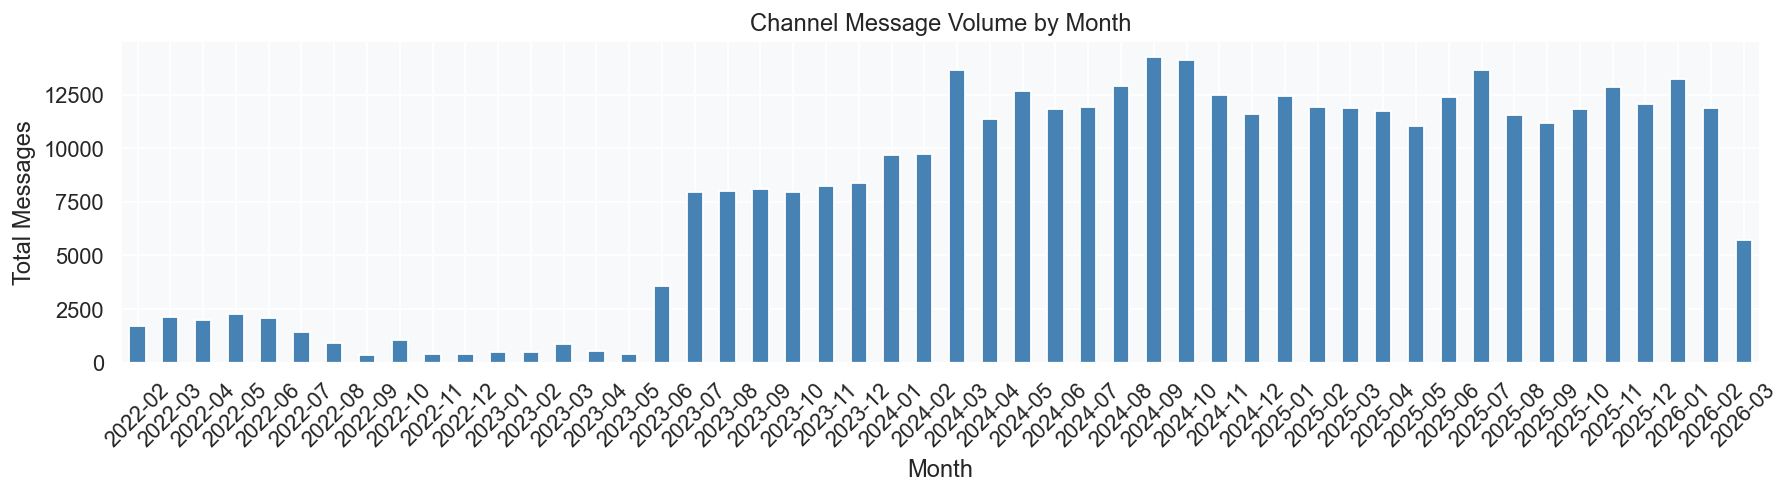

In [85]:
hourly_total = hourly.groupby('hour_slot')['tg_msg_count'].sum().reset_index()
hourly_total['month'] = hourly_total['hour_slot'].dt.to_period('M')
monthly = hourly_total.groupby('month')['tg_msg_count'].sum()

plt.figure(figsize=(14, 4))
monthly.plot(kind='bar', color='steelblue')
plt.title('Channel Message Volume by Month')
plt.xlabel('Month')
plt.ylabel('Total Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

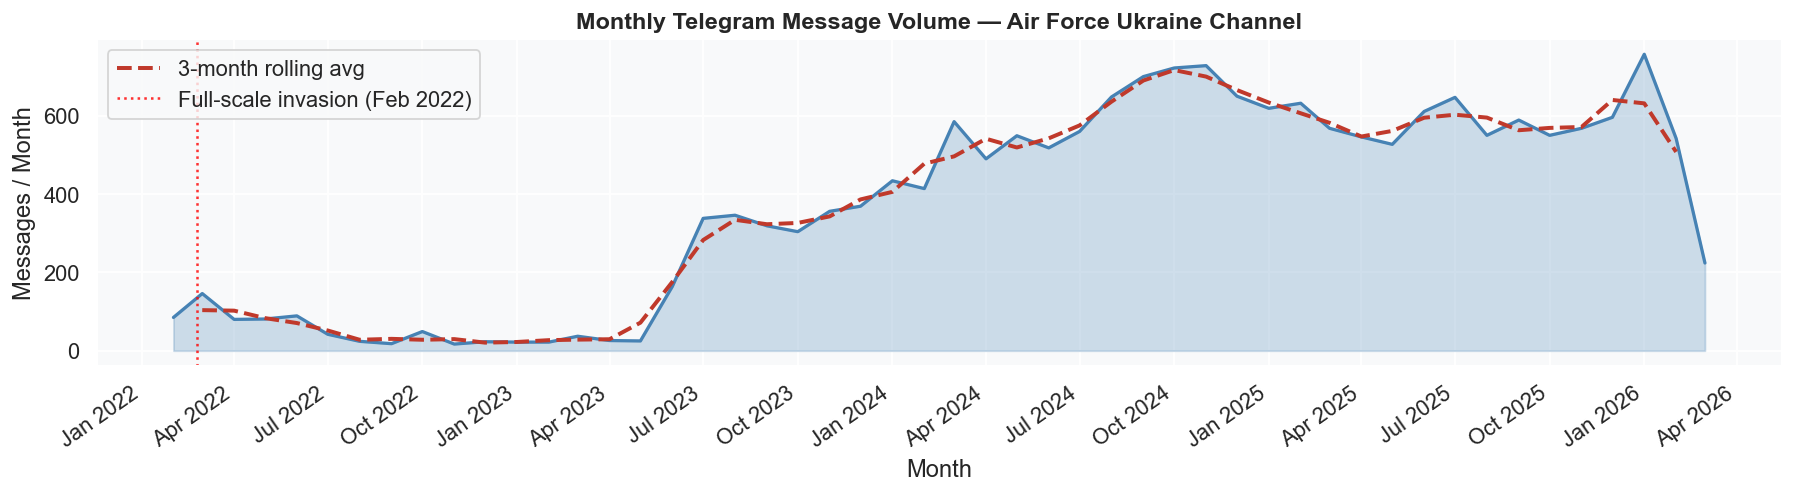

In [86]:
# One city proxy to avoid 23× inflation
city_proxy = hourly[hourly['city'] == 'Kyiv'].copy()
city_proxy['month'] = city_proxy['hour_slot'].dt.to_period('M')
monthly = city_proxy.groupby('month')['tg_msg_count'].sum().reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['month_dt'], monthly['tg_msg_count'],
                alpha=0.25, color='steelblue')
ax.plot(monthly['month_dt'], monthly['tg_msg_count'],
        color='steelblue', linewidth=1.8)

# Rolling 3-month average
rolling = monthly['tg_msg_count'].rolling(3, center=True).mean()
ax.plot(monthly['month_dt'], rolling,
        color='#c0392b', linewidth=2.2, linestyle='--', label='3-month rolling avg')

# Annotate full-scale invasion start
ax.axvline(pd.Timestamp('2022-02-24'), color='red', linewidth=1.4,
           linestyle=':', alpha=0.8, label='Full-scale invasion (Feb 2022)')

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=35, ha='right')
ax.set_title('Monthly Telegram Message Volume — Air Force Ukraine Channel', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Messages / Month')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Message volume starts high in early 2022 and grows steadily through 2023–2024**, peaking around late 2024 at roughly 650–700 messages/month.

**There are visible fluctuations throughout**, but the 3-month rolling average shows a clear upward trend from ~400 messages/month in mid-2023 to ~650 by late 2024.

**Volume stabilizes at a high level through 2025**, hovering around 600 messages/month with no significant decline.

**A sharp drop occurs at the very end of the dataset (early 2026)**, likely due to incomplete data for the most recent month rather than a real decrease in activity.

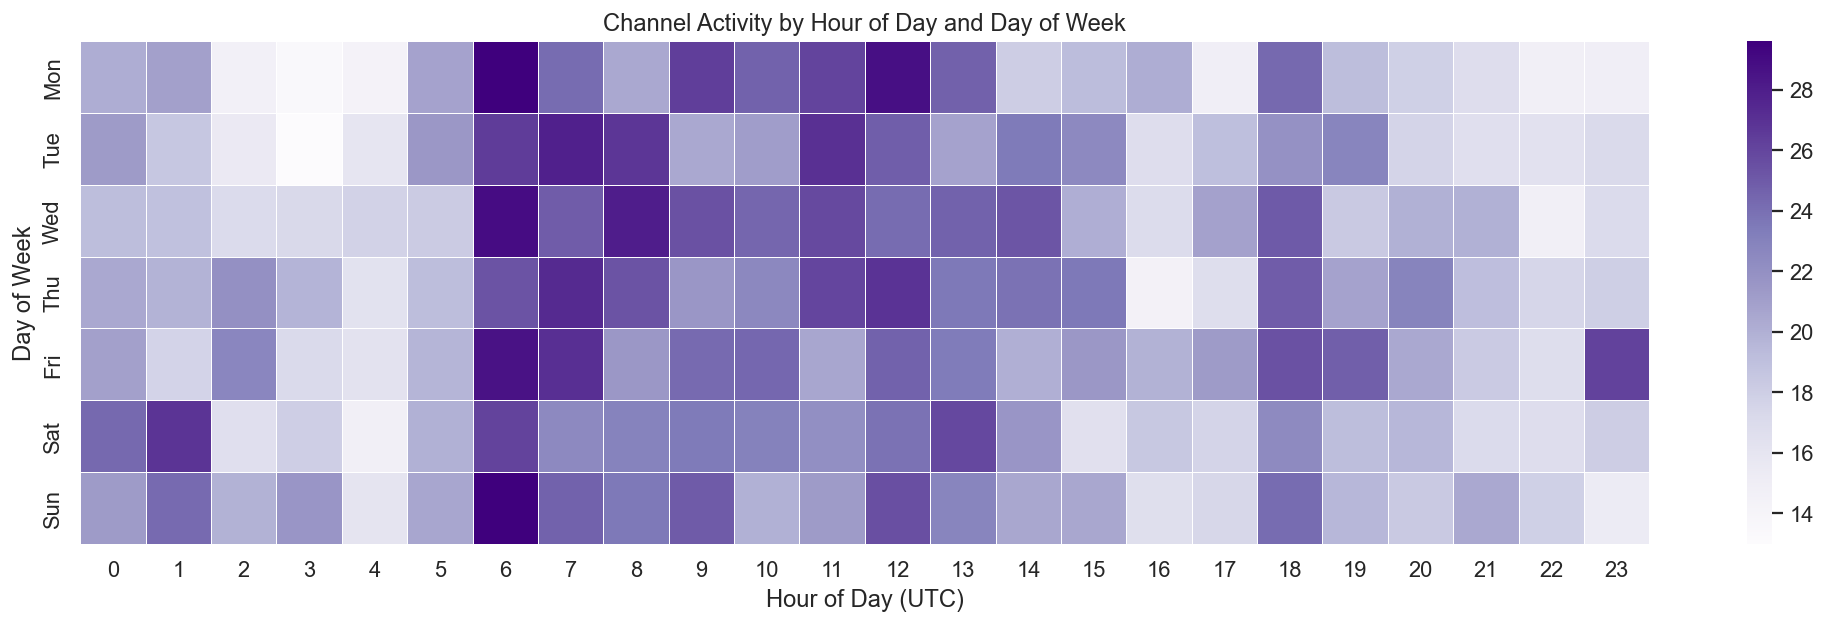

In [87]:
hourly_total2 = hourly.groupby('hour_slot')['tg_msg_count'].sum().reset_index()
hourly_total2['hour_of_day'] = hourly_total2['hour_slot'].dt.hour
hourly_total2['day_of_week'] = hourly_total2['hour_slot'].dt.dayofweek

heatmap_data = hourly_total2.groupby(['day_of_week', 'hour_of_day'])['tg_msg_count'].mean().unstack(fill_value=0)
heatmap_data.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='Purples', linewidths=0.3)
plt.title('Channel Activity by Hour of Day and Day of Week')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

**Activity peaks in the morning (8–9 Kyiv time) and around midday (13–15 Kyiv time)**, which aligns with typical working hours — likely reflecting when operators actively monitor and report.

**The quietest period is deep night (4–6 Kyiv time)**, consistently low across all days.

**Two late-night weekend spikes stand out** — Saturday around 3:00 and Saturday/Sunday around 1:00 Kyiv time. These isolated peaks likely correspond to overnight drone or missile waves, which Russia has historically favored on weekends to maximize disruption and catch air defense off-guard.

### 5.2 Overall Threat-Type Frequency

This chart shows how often each weapon type was mentioned across all hours and cities. 
Simply put — which threats the Air Force warned about most frequently throughout the war.

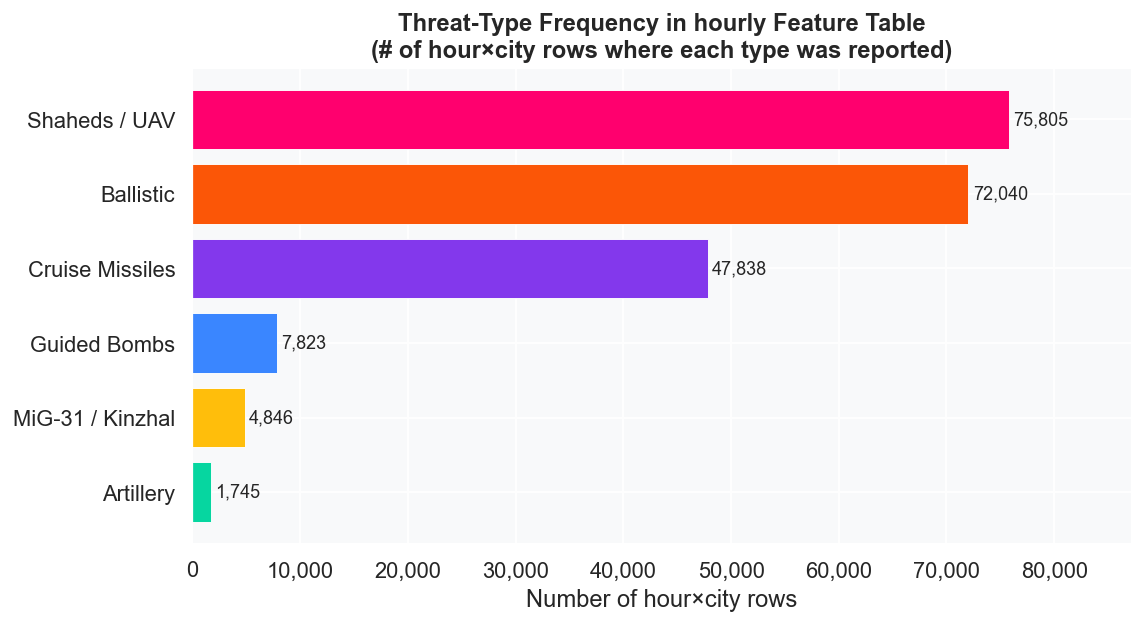


Raw totals:
  Shaheds / UAV            75,805
  Ballistic                72,040
  Cruise Missiles          47,838
  Guided Bombs              7,823
  MiG-31 / Kinzhal          4,846
  Artillery                 1,745


In [88]:
MY_COLOR_LIST = ['#FF006E', '#FB5607', '#FFBE0B', '#8338EC', '#3A86FF', '#06D6A0']

totals = (hourly[THREAT_COLS] > 0).sum().rename(dict(zip(THREAT_COLS, THREAT_LABELS)))
totals = totals.sort_values(ascending=True)

# Map each label to a colour from the custom palette
label_to_color = dict(zip(THREAT_LABELS, MY_COLOR_LIST))
bar_colors = [label_to_color[l] for l in totals.index]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

bars = ax.barh(totals.index, totals.values,
               color=bar_colors,
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, totals.values):
    ax.text(val + 400, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Threat-Type Frequency in hourly Feature Table\n'
             '(# of hour×city rows where each type was reported)', fontweight='bold')
ax.set_xlabel('Number of hour×city rows')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, totals.max() * 1.15)
plt.tight_layout()
plt.show()

print('\nRaw totals:')
for label, val in zip(totals.index[::-1], totals.values[::-1]):
    print(f'  {label:<22} {val:>8,}')

**Shaheds/UAVs and ballistic missiles dominate the dataset**, appearing in 75,796 and 71,361 hour×city rows respectively — nearly equal in frequency and together accounting for the majority of all reported threats.

**Cruise missiles are a distant third** at 47,838 rows, roughly 35% less frequent than the top two categories.

**Artillery, guided bombs, and Kinzhal appear significantly less often** — 17,445, 9,515, and 4,846 rows respectively — likely because their range limits the number of affected cities per event.

**The class imbalance is significant for modeling**: Shaheds and ballistics together outnumber Kinzhal entries by roughly 15:1, which will need to be accounted for during training.

### 5.3 City × Threat-Type Heatmap

This chart shows which weapon types each city was most exposed to. 
Each row is a city, each column is a weapon type. 
The color shows the share of that city's total threats — so you can compare cities fairly 
regardless of how often they appear in the data. The numbers inside are the raw counts.

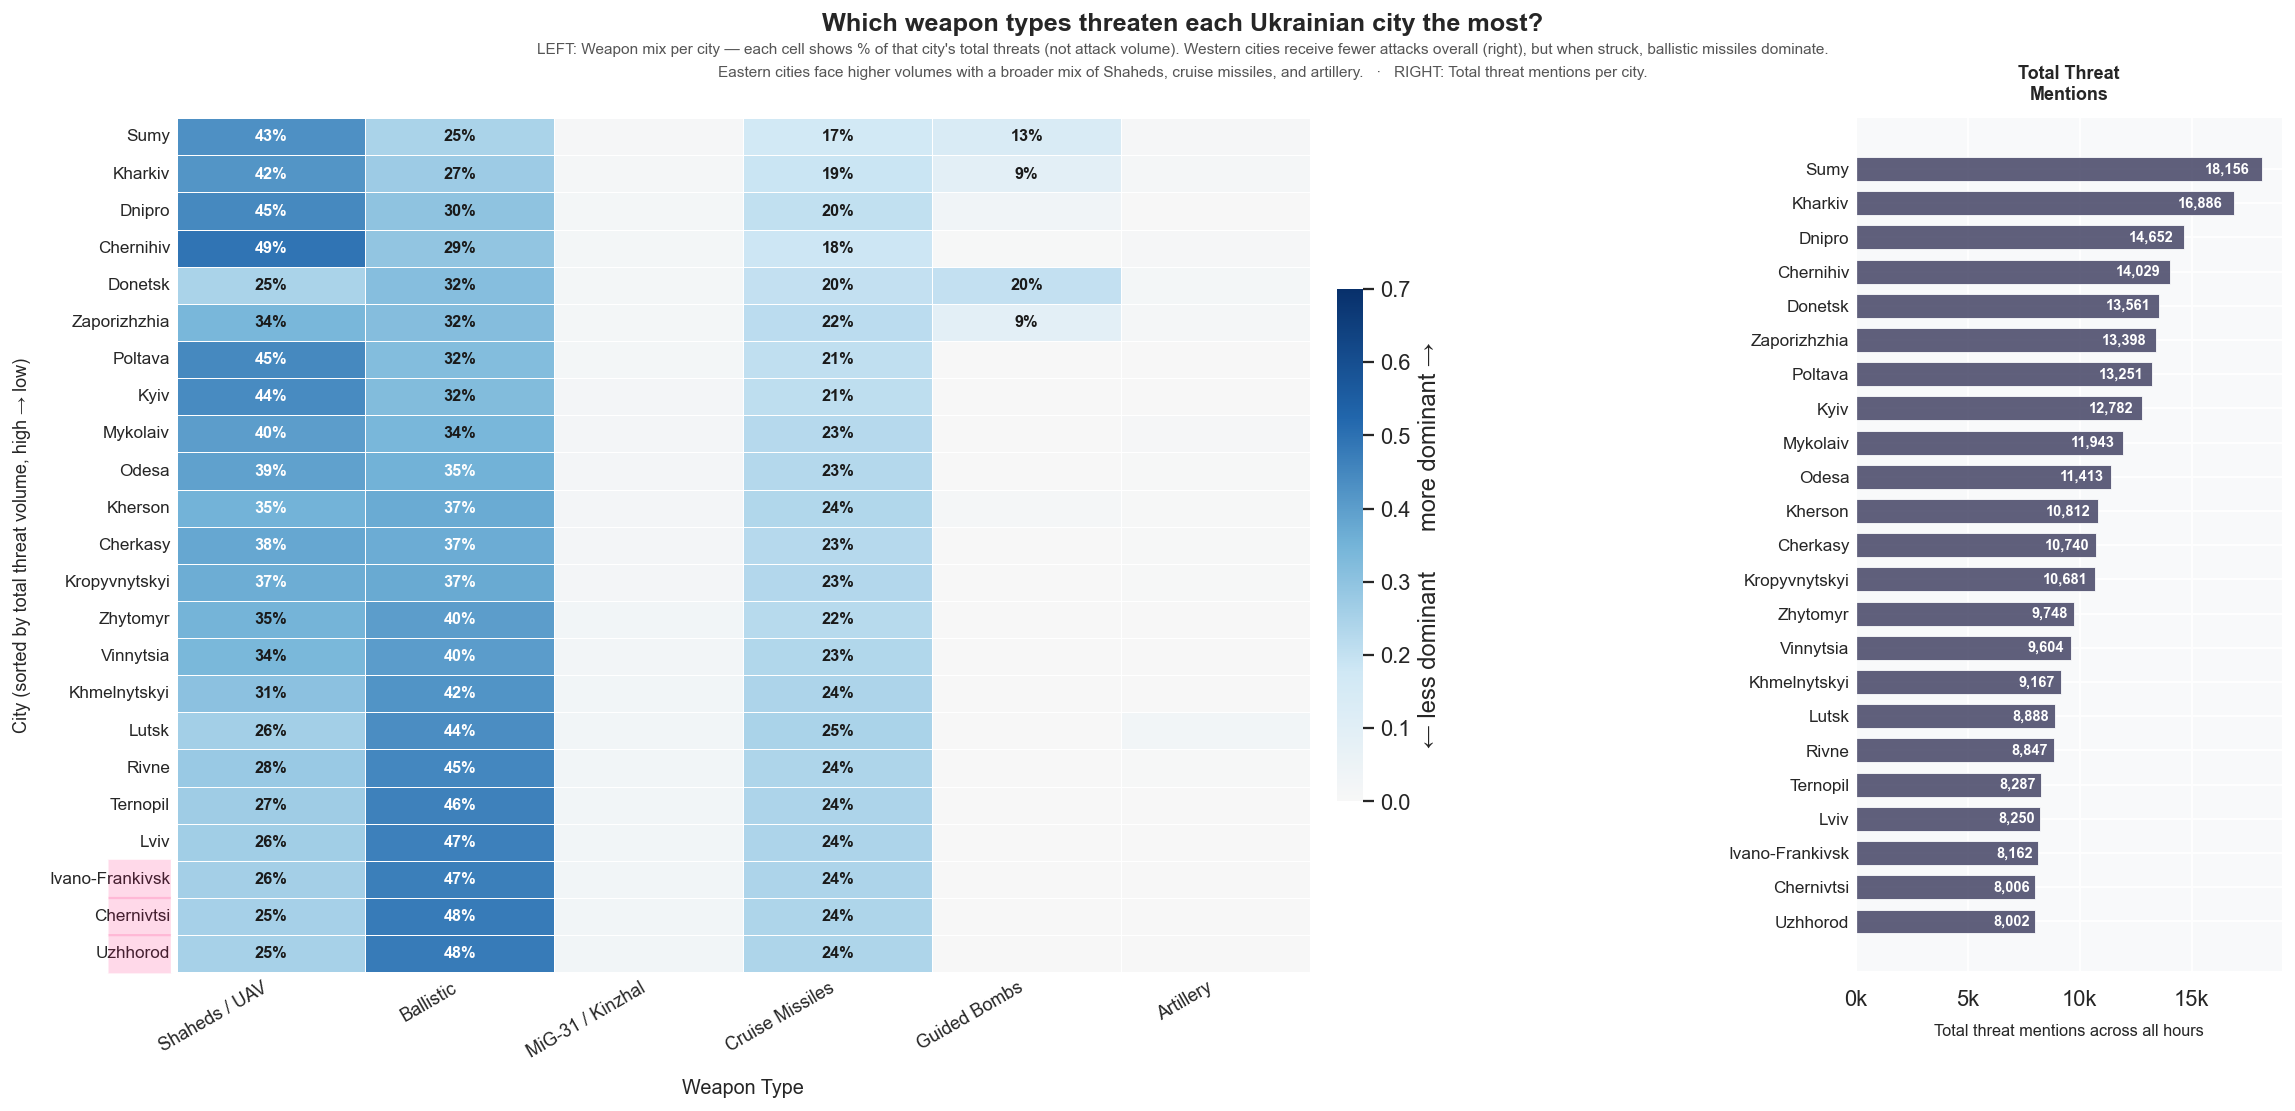

In [89]:
MY_COLOR_LIST = ['#FF006E', '#FB5607', '#FFBE0B', '#8338EC', '#3A86FF']

# More contrast heatmap: light grey → deep navy
custom_cmap = LinearSegmentedColormap.from_list(
    'custom', ['#f7f7f7', '#d0e8f5', '#74b4d8', '#2166ac', '#08306b'], N=256
)

city_threat = hourly.groupby('city')[THREAT_COLS].sum()
city_threat.columns = THREAT_LABELS
city_threat_norm = city_threat.div(city_threat.sum(axis=1), axis=0)
city_order = city_threat.sum(axis=1).sort_values(ascending=False).index
city_threat_norm = city_threat_norm.loc[city_order]
city_threat_sorted = city_threat.loc[city_order]
city_totals = city_threat_sorted.sum(axis=1)

pct_annot = city_threat_norm.applymap(lambda x: f'{x*100:.0f}%' if x >= 0.05 else '')

fig, axes = plt.subplots(1, 2, figsize=(18, 9),
                          gridspec_kw={'width_ratios': [3.2, 1]},
                          facecolor='white')
fig.subplots_adjust(wspace=0.35, left=0.07, right=0.97, top=0.88, bottom=0.15)

# ── LEFT: Heatmap ────────────────────────────────────────────────────────────
sns.heatmap(
    city_threat_norm,
    ax=axes[0],
    cmap=custom_cmap,
    vmin=0, vmax=0.7,
    annot=pct_annot,
    fmt='',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '← less dominant      more dominant →',
              'shrink': 0.6, 'aspect': 20, 'pad': 0.02},
    annot_kws={'size': 9, 'fontweight': 'bold'},
)

# Fix annotation colors: white on dark cells, dark on light cells
for text, val in zip(axes[0].texts, city_threat_norm.values.flatten()):
    text.set_color('white' if val >= 0.35 else '#1a1a1a')

axes[0].set_xlabel('Weapon Type', fontsize=11, labelpad=10)
axes[0].set_ylabel('City (sorted by total threat volume, high → low)', fontsize=10, labelpad=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=10)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9.5)
axes[0].tick_params(length=0)

for i in range(3):
    axes[0].add_patch(mpatches.FancyBboxPatch(
        (-0.02, len(city_order) - i - 1.02), -0.35, 1.04,
        boxstyle='round,pad=0.01', linewidth=0,
        facecolor='#FF006E', alpha=0.15,
        transform=axes[0].transData, clip_on=False
    ))

# ── RIGHT: Horizontal bar chart ──────────────────────────────────────────────
n = len(city_totals)
bars = axes[1].barh(
    range(n), city_totals.values[::-1],
    color='#4A4A6A', alpha=0.88,
    height=0.7, edgecolor='white', linewidth=0.5
)

for i, val in enumerate(city_totals.values[::-1]):
    axes[1].text(
        val * 0.97, i,
        f'{val:,}',
        va='center', ha='right',
        fontsize=8, color='white', fontweight='bold'
    )

axes[1].set_yticks(range(n))
axes[1].set_yticklabels(city_totals.index[::-1], fontsize=9.5)
axes[1].set_xlabel('Total threat mentions across all hours', fontsize=9, labelpad=8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(axis='y', length=0)

fig.suptitle('Which weapon types threaten each Ukrainian city the most?',
             fontsize=14, fontweight='bold', y=0.97)
fig.text(0.5, 0.935,
         'LEFT: Weapon mix per city — each cell shows % of that city\'s total threats (not attack volume). '
         'Western cities receive fewer attacks overall (right), but when struck, ballistic missiles dominate.',
         ha='center', fontsize=8.5, color='#555555')
fig.text(0.5, 0.915,
         'Eastern cities face higher volumes with a broader mix of Shaheds, cruise missiles, and artillery.   ·   '
         'RIGHT: Total threat mentions per city.',
         ha='center', fontsize=8.5, color='#555555')
axes[0].set_title('')
axes[1].set_title('Total Threat\nMentions', fontsize=10, fontweight='bold', pad=10)
plt.show()

**Eastern front-line cities face the highest overall threat volume**, with Sumy, Kharkiv, and Dnipro recording over 14,000–17,000 threat mentions — roughly twice that of western cities.

**Weapon mix shifts clearly by geography.** Eastern cities show a higher Shahed share (45–50%) reflecting proximity to launch positions and the volume of drone campaigns. Western cities are struck less frequently overall, but ballistic missiles account for 45–48% of their threat mix — the only weapon system with sufficient range to reach them consistently.

**Donetsk stands out with the highest guided bomb share (~10%)**, consistent with its front-line position where Russian aircraft operate within glide bomb range.

**Artillery is now correctly absent for non-frontline cities** — after zeroing out proximity weapons for nationwide broadcast messages, only Sumy and Kharkiv retain a meaningful artillery signal, which accurately reflects their exposure to cross-border shelling.

### 5.4 Temporal Activity Patterns — Hour of Day & Day of Week

This chart answers: when does the channel post the most, and when do actual threats peak? 
The bars show average message volume per hour, the red line shows how often a threat was detected. 
The day-of-week chart does the same breakdown by weekday.

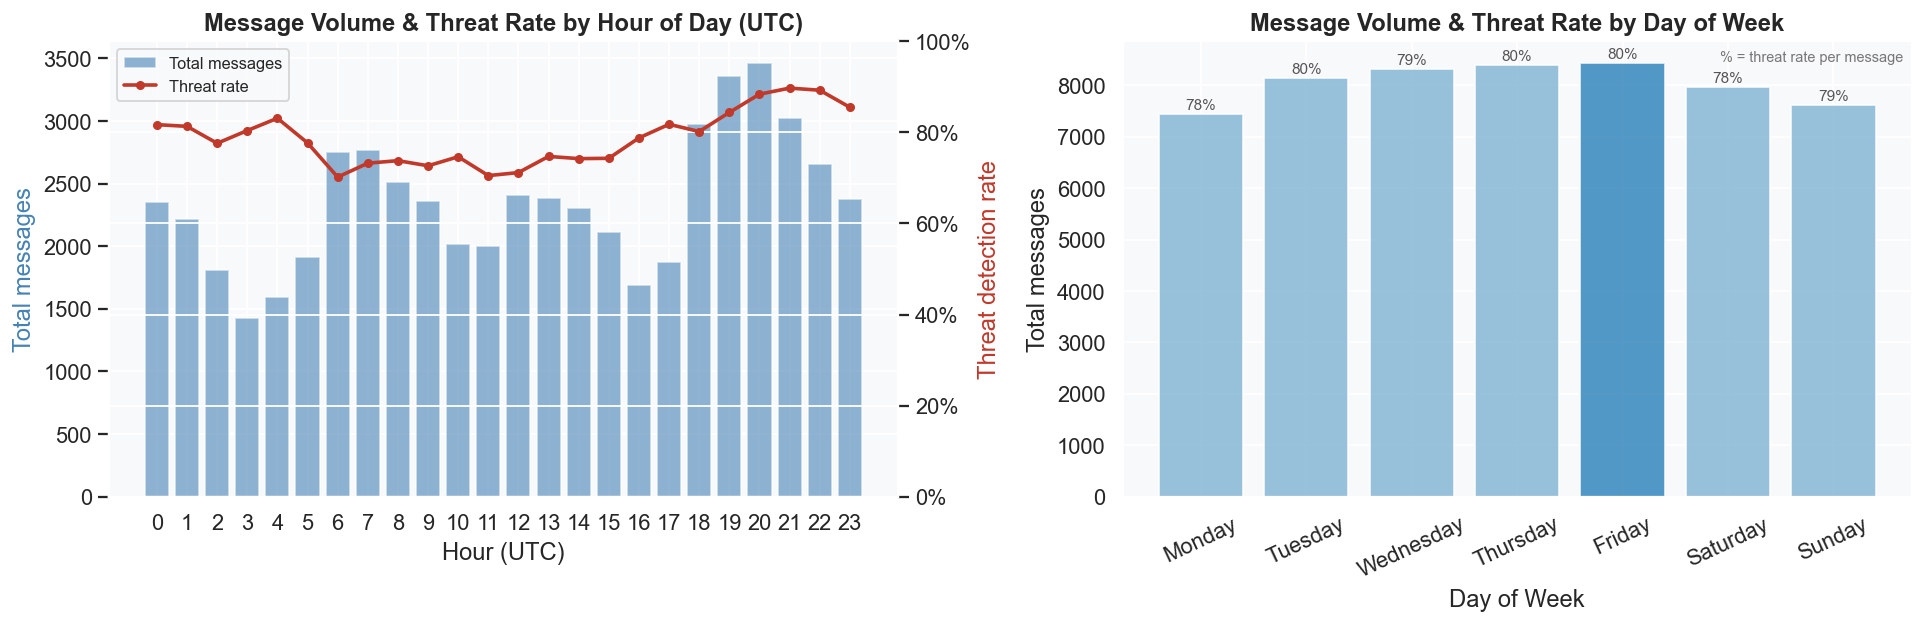

In [90]:
# Deduplicate by keeping first occurrence of each original message
# (df_exploded has no 'id' column — deduplicate on date + text_clean instead)
df_time = df_exploded.drop_duplicates(subset=['date', 'text_clean']).copy()
df_time['hour']       = df_time['date'].dt.hour
df_time['weekday']    = df_time['date'].dt.day_name()
df_time['any_threat'] = (df_time[threat_cols].sum(axis=1) > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Hour of day ───────────────────────────────────────────────────────────────
hourly_avg   = df_time.groupby('hour')[['any_threat']].mean()
msg_per_hour = df_time.groupby('hour').size()

axes[0].bar(msg_per_hour.index, msg_per_hour.values,
            color='steelblue', alpha=0.6, label='Total messages')
ax2 = axes[0].twinx()
ax2.plot(hourly_avg.index, hourly_avg['any_threat'],
         color='#c0392b', linewidth=2, marker='o', markersize=4, label='Threat rate')

axes[0].set_title('Message Volume & Threat Rate by Hour of Day (UTC)', fontweight='bold')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Total messages', color='steelblue')
ax2.set_ylabel('Threat detection rate', color='#c0392b')
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].set_xticks(range(0, 24))
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ── Day of week ───────────────────────────────────────────────────────────────
dow_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_count  = df_time.groupby('weekday').size().reindex(dow_order)
dow_threat = df_time.groupby('weekday')['any_threat'].mean().reindex(dow_order)

colors = ['#2980b9' if v == dow_count.max() else '#7fb3d3' for v in dow_count]
axes[1].bar(dow_order, dow_count.values, color=colors, alpha=0.8)
axes[1].set_title('Message Volume & Threat Rate by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total messages')
axes[1].tick_params(axis='x', rotation=25)

for i, (d, rate) in enumerate(dow_threat.items()):
    axes[1].text(i, dow_count[d] + dow_count.max() * 0.01,
                 f'{rate:.0%}', ha='center', fontsize=8.5, color='#555')
axes[1].text(0.99, 0.98, '% = threat rate per message',
             transform=axes[1].transAxes,
             ha='right', va='top', fontsize=8, color='#777')

plt.tight_layout()
plt.show()

**Message volume peaks in the evening (19–21 UTC) and again around 6 UTC**, which reflects the channel's publication schedule — evening summaries and the morning overnight report — rather than actual attack timing.

**Threat rate is highest in the early morning hours (4–6 UTC)**, which aligns with the overnight report batch: fewer individual messages are posted, but nearly all of them are threat alerts from the night's accumulated activity.

**Day of week is flat at 80–82%** — the channel reports consistently regardless of day, confirming it as a reliable continuous signal source.

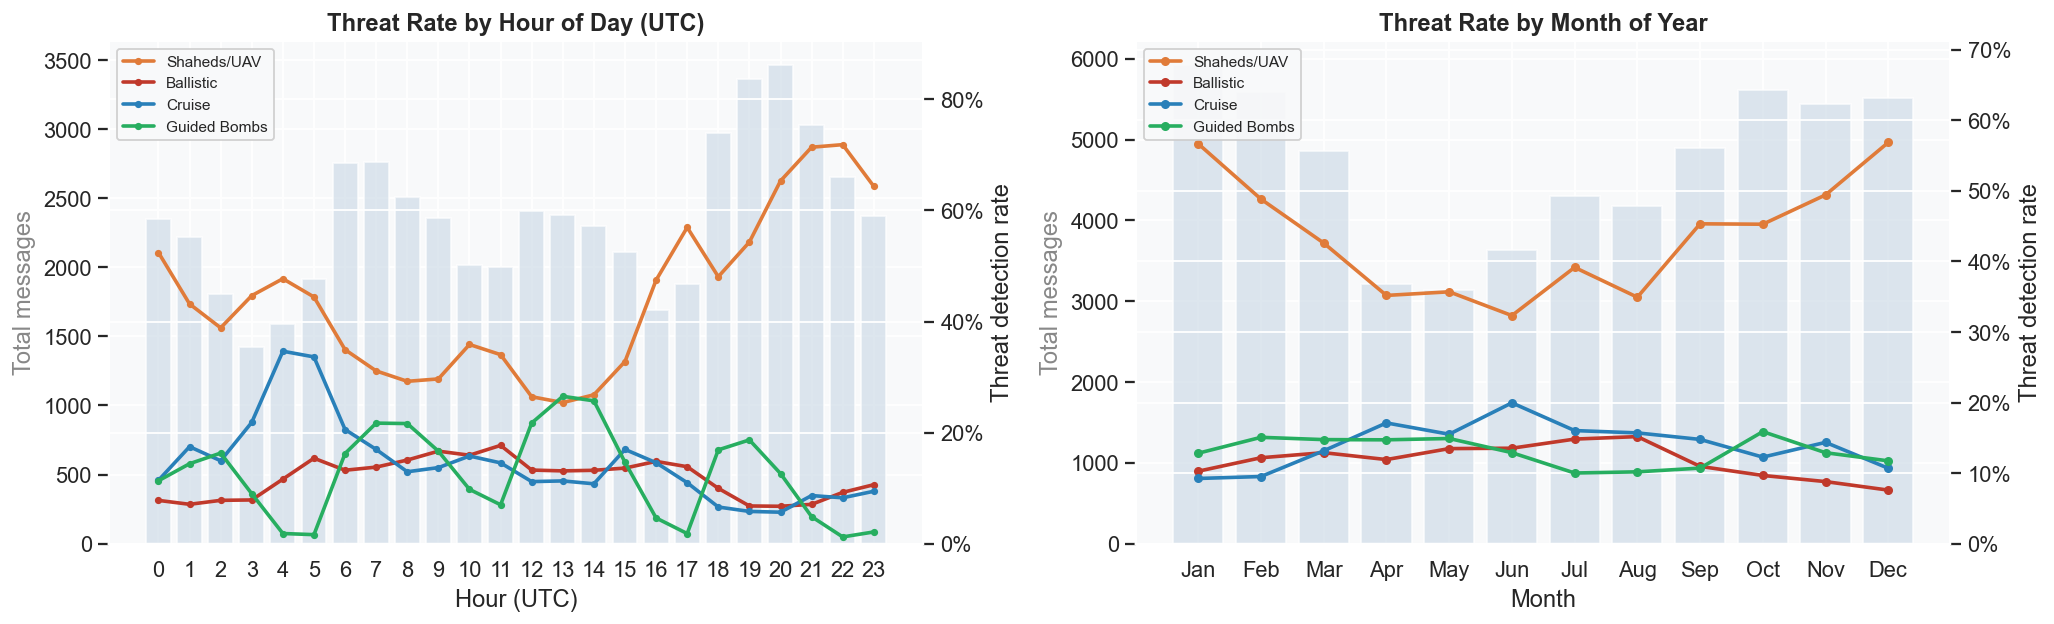

In [91]:
PLOT_THREATS = OrderedDict([
    ('tg_shaheds',      ('#e07b39', 'Shaheds/UAV')),
    ('tg_ballistic',    ('#c0392b', 'Ballistic')),
    ('tg_cruise',       ('#2980b9', 'Cruise')),
    ('tg_guided_bombs', ('#27ae60', 'Guided Bombs')),
])

df_time = df_exploded.drop_duplicates(subset=['date', 'text_clean']).copy()
df_time['hour']      = df_time['date'].dt.hour
df_time['month_num'] = df_time['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── LEFT: Hour of day ─────────────────────────────────────────────────────────
msg_per_hour = df_time.groupby('hour').size()
axes[0].bar(msg_per_hour.index, msg_per_hour.values,
            color='#d0dce8', alpha=0.7, label='Total messages', zorder=1)

ax2 = axes[0].twinx()
for col, (color, label) in PLOT_THREATS.items():
    rate = df_time.groupby('hour')[col].mean()
    ax2.plot(rate.index, rate.values,
             color=color, linewidth=2, marker='o', markersize=3,
             label=label, zorder=2)

axes[0].set_title('Threat Rate by Hour of Day (UTC)', fontweight='bold')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Total messages', color='#888')
ax2.set_ylabel('Threat detection rate')
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.2)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].set_xticks(range(0, 24))
ax2.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

# ── RIGHT: Month of year ──────────────────────────────────────────────────────
msg_per_month = df_time.groupby('month_num').size()
axes[1].bar(msg_per_month.index, msg_per_month.values,
            color='#d0dce8', alpha=0.7, label='Total messages', zorder=1)

ax3 = axes[1].twinx()
for col, (color, label) in PLOT_THREATS.items():
    rate = df_time.groupby('month_num')[col].mean()
    ax3.plot(rate.index, rate.values,
             color=color, linewidth=2, marker='o', markersize=4,
             label=label, zorder=2)

axes[1].set_title('Threat Rate by Month of Year', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total messages', color='#888')
ax3.set_ylabel('Threat detection rate')
ax3.set_ylim(0, ax3.get_ylim()[1] * 1.2)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
ax3.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.show()

**The Shahed peak at 2–5 UTC reflects genuine real-time reporting** — drones are tracked and reported continuously as they move across regions, often over several hours overnight. The early morning cluster is real attack activity, not a reporting lag.

**The guided bomb spike at 4–6 UTC is likely an artifact** — guided bombs require daylight and aircraft proximity to the front, so any early-morning signal is almost certainly from the overnight summary report rather than a live alert.

**The seasonal Shahed peak in November–December remains meaningful** — it reflects the genuine escalation of drone campaigns during Russia's winter energy infrastructure strikes.

### 5.5 Threat Composition Over Time (Monthly Stacked Area)

This chart shows how the mix of weapon types changed month by month throughout the war. 
Each colored band is a weapon type — you can see shaheds (drones) barely existed before 
autumn 2022, then rapidly became the dominant threat. Guided bombs grew steadily from 2023 onward.

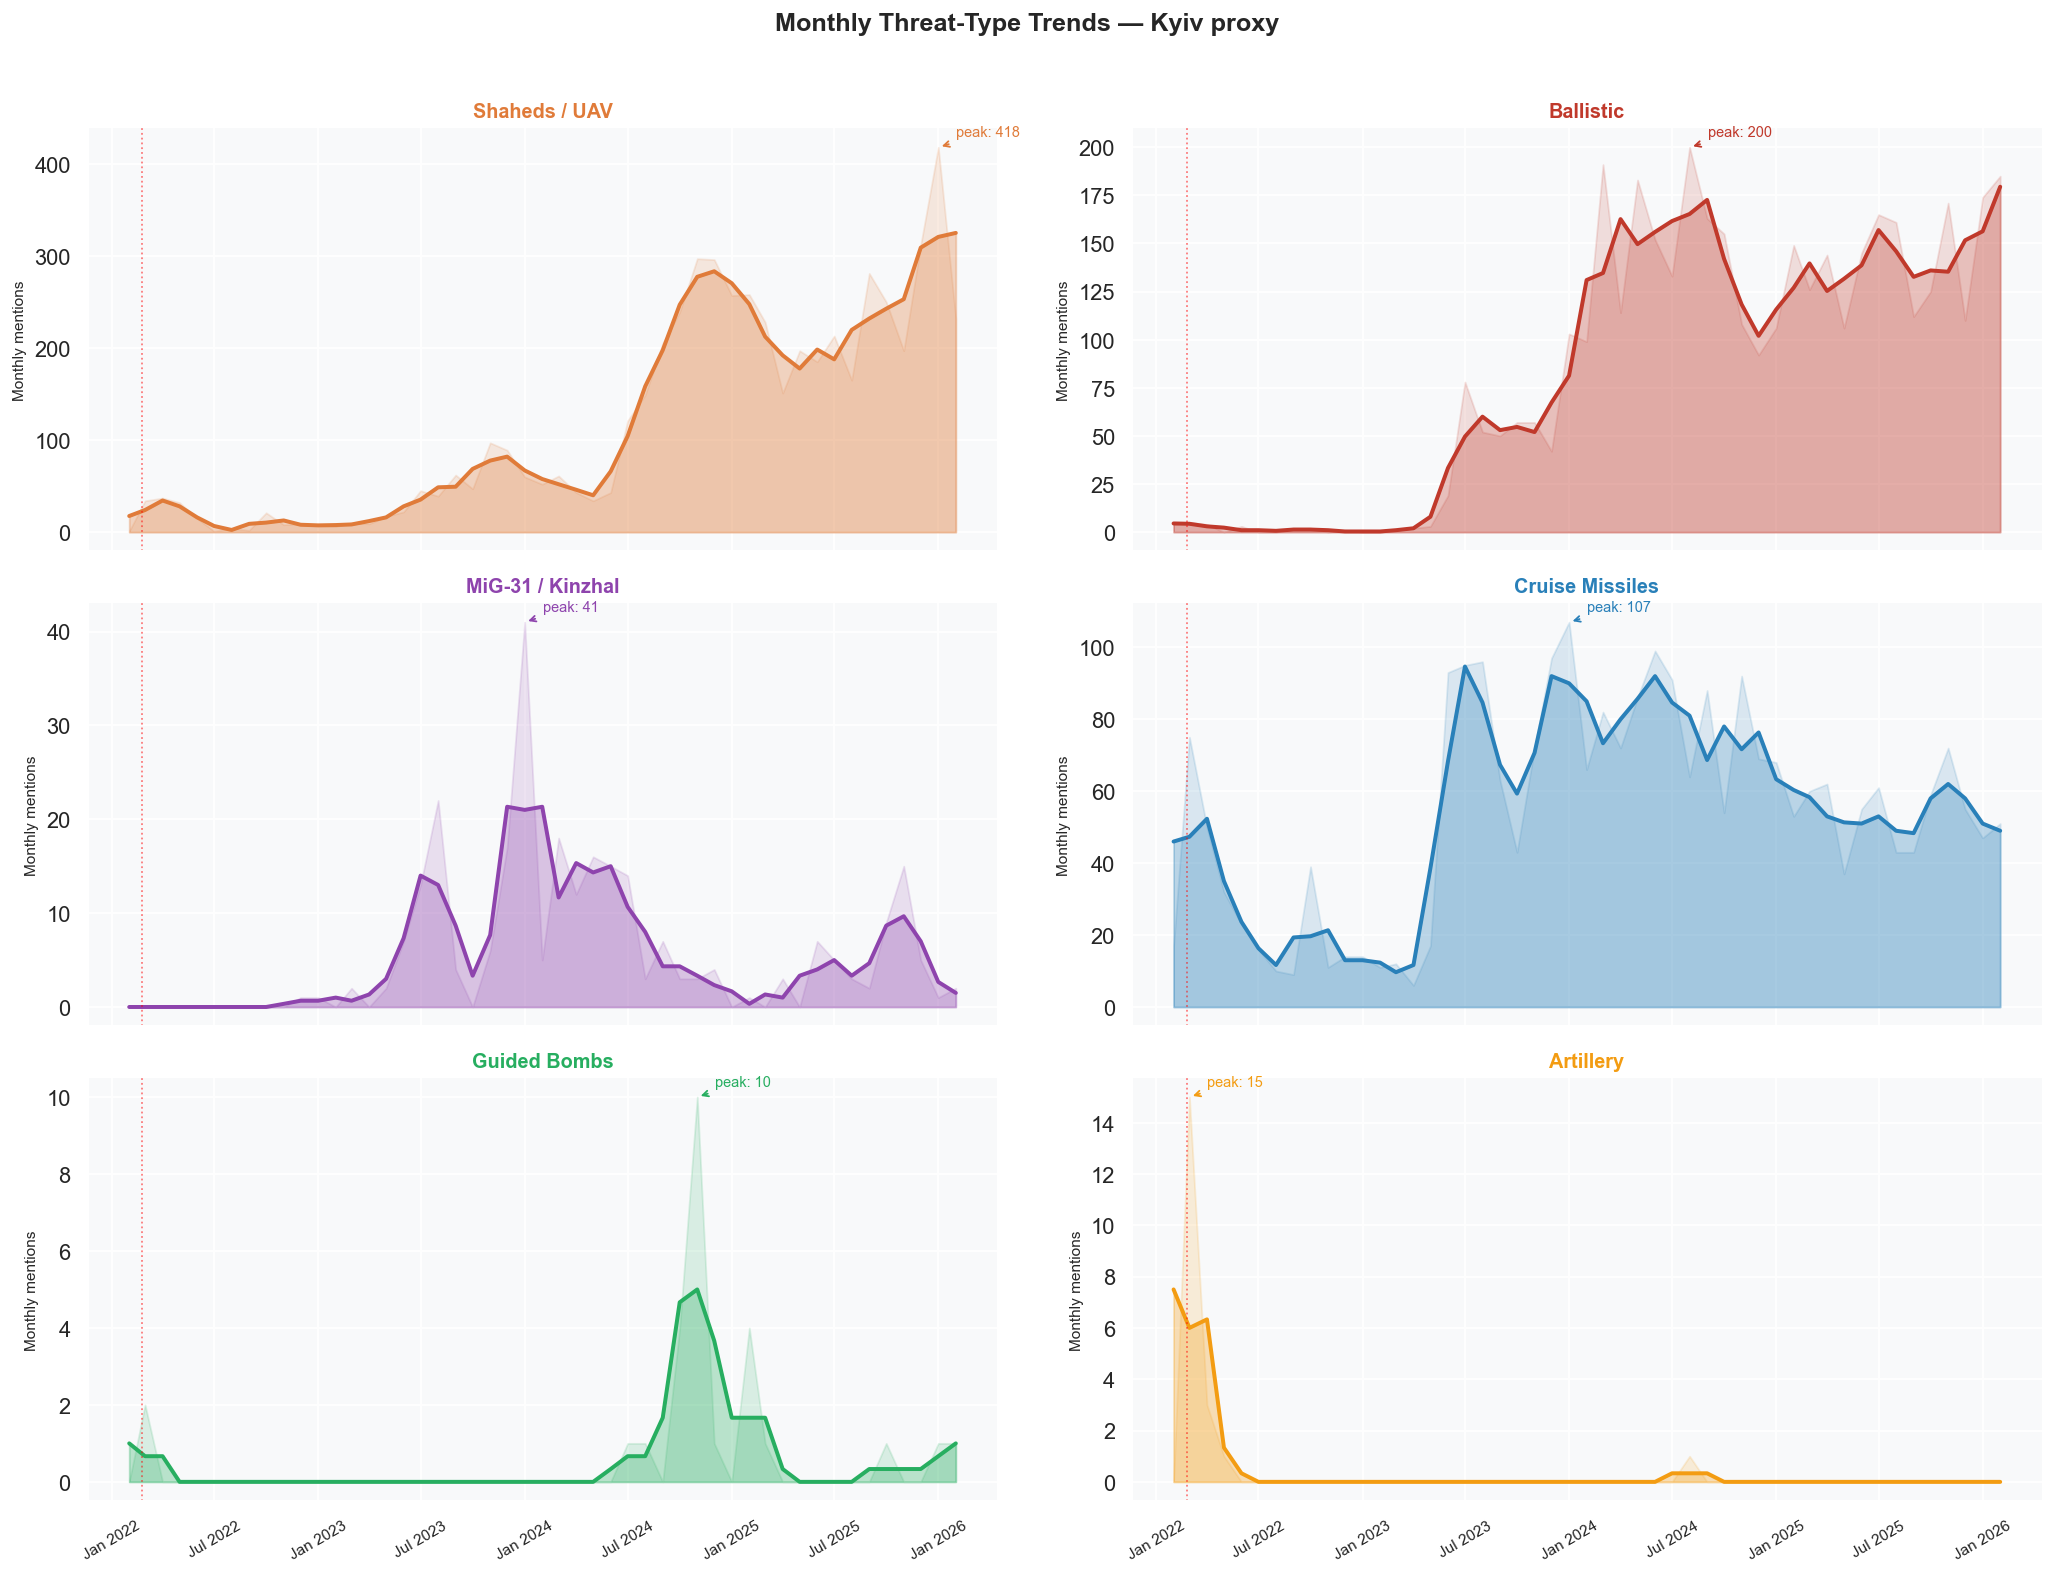

In [92]:
cp2 = hourly[hourly['city'] == 'Kyiv'].copy()
cp2['month'] = cp2['hour_slot'].dt.to_period('M')
monthly_threat = cp2.groupby('month')[THREAT_COLS].sum()
monthly_threat.columns = THREAT_LABELS
monthly_threat.index = monthly_threat.index.to_timestamp()

if monthly_threat.index[-1].month == hourly['hour_slot'].max().month:
    monthly_threat = monthly_threat.iloc[:-1]

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for ax, label, color in zip(axes, THREAT_LABELS, THREAT_COLORS):
    raw    = monthly_threat[label]
    rolled = raw.rolling(3, center=True, min_periods=1).mean()

    ax.fill_between(monthly_threat.index, raw, alpha=0.15, color=color)
    ax.fill_between(monthly_threat.index, rolled, alpha=0.3, color=color)
    ax.plot(monthly_threat.index, rolled, color=color, linewidth=2.2)

    # Annotate max point
    peak_idx = raw.idxmax()
    peak_val = raw.max()
    ax.annotate(f'peak: {int(peak_val):,}',
                xy=(peak_idx, peak_val),
                xytext=(10, 6), textcoords='offset points',
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax.axvline(pd.Timestamp('2022-02-24'), color='red',
               linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title(label, fontweight='bold', color=color, fontsize=11)
    ax.set_ylabel('Monthly mentions', fontsize=8.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Monthly Threat-Type Trends — Kyiv proxy',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [99]:
kyiv_bombs = df_exploded[
    (df_exploded['city'] == 'Kyiv') & 
    (df_exploded['tg_guided_bombs'] == 1)
]

for _, row in kyiv_bombs.iterrows():
    words = row['text_raw'].split()
    truncated_text = " ".join(words[:30]) + ("..." if len(words) > 30 else "")
    
    print(f"Date: {row['date']}")
    print(f"Key words: {matches}")
    print(f"Text (truncated): {truncated_text}")
    print("-" * 50)

Date: 2022-03-19 12:03:50
Key words: ['каб']
Text (truncated): 🇺🇦 Оперативна інформація станом на 12.00 19.03.2022 щодо російського_вторгнення Триває двадцять четверта доба героїчного протистояння Українського народу російському воєнному вторгненню. Російські окупаційні війська намагаються продовжувати стратегічну наступальну операцію проти України....
--------------------------------------------------
Date: 2022-03-19 18:08:27
Key words: ['каб']
Text (truncated): 🇺🇦 Оперативна інформація станом на 18.00 19.03.2022 щодо російського вторгнення Триває двадцять четверта доба героїчного протистояння Українського народу повномасштабній збройній агресії РФ Оперативна обстановка суттєвих змін не зазнала. Захисники України...
--------------------------------------------------
Date: 2024-07-14 12:13:05
Key words: ['каб']
Text (truncated): 📢 Відбій загрози для Київської та Чернігівської областей. 🚀Пуски КАБ тактичною авіацією на Харківщині!
--------------------------------------------------
Date

In [102]:
kyiv_bombs = df_exploded[
    (df_exploded['city'] == 'Kyiv') & 
    (df_exploded['tg_artillery'] == 1)
]

for _, row in kyiv_bombs.iterrows():
    words = row['text_raw'].split()
    truncated_text = " ".join(words[:30]) + ("..." if len(words) > 30 else "")
    
    print(f"Date: {row['date']}")
    print(f"Key words: {matches}")
    print(f"Text (truncated): {truncated_text}")
    print("-" * 50)

Date: 2022-03-03 07:19:41
Key words: ['каб']
Text (truncated): Оперативне зведення ЗС України 🇺🇦 Оперативна інформація станом на 06.00 03.03.2022 щодо #російського_вторгнення Триває восьма доба героїчного протистояння Українського народу російському воєнному вторгненню. Окупаційні війська, не досягнувши успіху майже на...
--------------------------------------------------
Date: 2022-03-04 17:29:05
Key words: ['каб']
Text (truncated): Оперативна інформація станом на 18.00 04.03.2022 щодо російського вторгнення Відео https://www.youtube.com/watch?v=g2oBcD6EZkU Триває дев’ята доба героїчного протистояння Українського народу російському воєнному вторгненню. Основні зусилля окупантів зосереджувались на оточенні Києва та послабленні...
--------------------------------------------------
Date: 2022-03-13 11:34:16
Key words: ['каб']
Text (truncated): Генеральний штаб ЗСУ: Оперативна інформація станом на 12.00 13.03.2022 щодо російського вторгнення Триває вісімнадцята доба героїчного протистоянн

**Shaheds show a clear and steady escalation** from near-zero in early 2022 to a peak of 416 monthly mentions by early 2026 — the most dramatic growth trend of any weapon type, reflecting Russia's increasing reliance on drone campaigns over time.

**Ballistic missiles ramped up sharply through 2023–2024**, peaking at 192 mentions, and have remained at an elevated plateau since — suggesting sustained and consistent use rather than episodic campaigns.

**Cruise missiles were the dominant long-range weapon in 2022**, spiking immediately after invasion day, then declining as ballistics and Shaheds took over. Activity stabilizes at a lower but consistent level from 2023 onward.

**Kinzhal/MiG-31 shows sharp episodic spikes** rather than a steady trend — peak of 41 in mid-2024 — consistent with its use as a high-value precision weapon deployed selectively rather than in mass campaigns.

**Guided bombs show one separate mention of Kyiv, and artillery is also mentioned at the beginning of 2022** — both indicators are correct, although at first glance there should be no correspondence. Aerial bombs are mentioned in joint messages where both Kyiv and the eastern territories are mentioned, but 10 mentions do not have a critical impact on the final dataset. Artillery is mentioned at the beginning of the full-scale in daily reports, the number of mentions is also not critical.

### 5.6 Year-over-Year Threat Breakdown

A simple yearly comparison of how many times each weapon type was reported. 
At a glance you can see how Russian tactics shifted: missiles dominated in 2022, 
drones took over in 2023, and guided bombs escalated through 2024–2025.

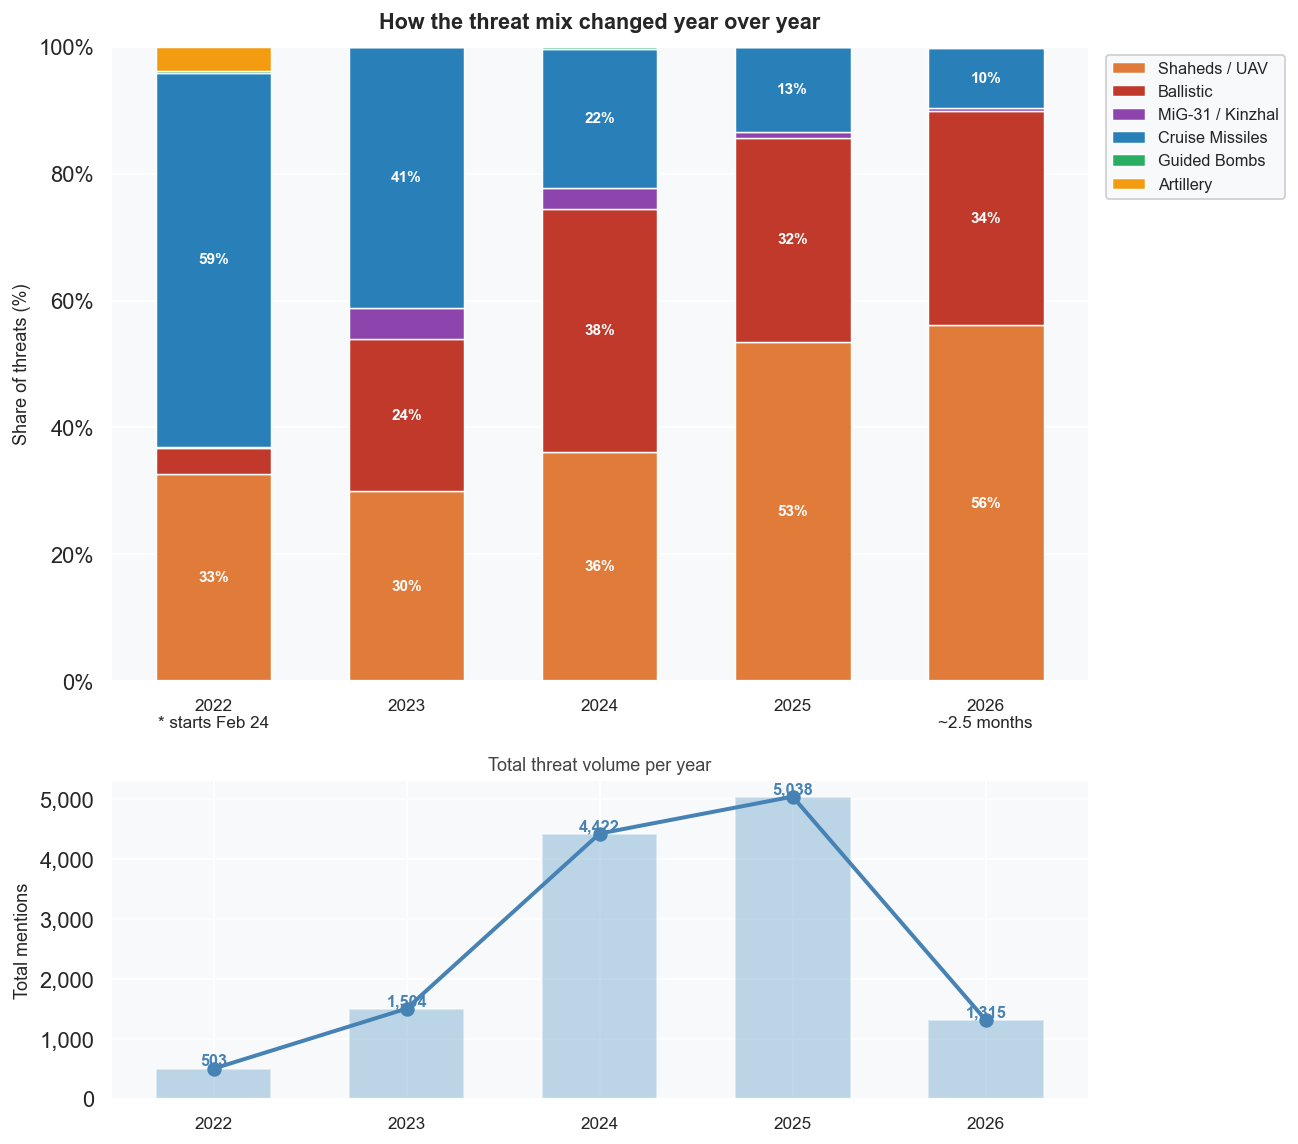

In [95]:
cp3 = hourly[hourly['city'] == 'Kyiv'].copy()
cp3['year'] = cp3['hour_slot'].dt.year
yearly = cp3.groupby('year')[THREAT_COLS].sum()
yearly.columns = THREAT_LABELS

# Нормалізуємо до 100% для кожного року
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100
yearly_total = yearly.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 9),
                          gridspec_kw={'height_ratios': [2, 1]})

# ── TOP: 100% stacked bar ─────────────────────────────────────────────────────
bottom = pd.Series([0.0] * len(yearly_pct), index=yearly_pct.index)
for label, color in zip(THREAT_LABELS, THREAT_COLORS):
    values = yearly_pct[label]
    bars = axes[0].bar(yearly_pct.index, values, bottom=bottom,
                       color=color, label=label,
                       edgecolor='white', linewidth=0.8, width=0.6)
    # Label inside bar if large enough
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val > 5:
            axes[0].text(
                yearly_pct.index[i], bot + val / 2,
                f'{val:.0f}%',
                ha='center', va='center',
                fontsize=8.5, color='white', fontweight='bold'
            )
    bottom += values

axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Share of threats (%)', fontsize=10)
axes[0].set_title('How the threat mix changed year over year',
                  fontsize=12, fontweight='bold', pad=10)
axes[0].set_xticks(yearly_pct.index)
axes[0].set_xticklabels([f'{y}\n* starts Feb 24' if y == 2022
                          else f'{y}\n~2.5 months' if y == 2026
                          else str(y)
                          for y in yearly_pct.index], fontsize=9.5)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), 
               fontsize=9, ncol=1, framealpha=0.9)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))

# ── BOTTOM: Total volume line ─────────────────────────────────────────────────
axes[1].bar(yearly_total.index, yearly_total.values,
            color='#7fb3d3', alpha=0.5, width=0.6, edgecolor='white')
axes[1].plot(yearly_total.index, yearly_total.values,
             color='steelblue', linewidth=2.2, marker='o', markersize=7)

for x, val in zip(yearly_total.index, yearly_total.values):
    axes[1].text(x, val + 50, f'{val:,}',
                 ha='center', fontsize=9, color='steelblue', fontweight='bold')

axes[1].set_ylabel('Total mentions', fontsize=10)
axes[1].set_title('Total threat volume per year', fontsize=10,
                  color='#444', pad=6)
axes[1].set_xticks(yearly_total.index)
axes[1].set_xticklabels(yearly_total.index, fontsize=9.5)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

**Total threat volume grew nearly tenfold from 2022 to 2025**, rising from 482 mentions (10 months) to 4,957 — reflecting both the escalation of the war and Russia's expanding strike arsenal.

**The weapon mix shifted dramatically over time.** Cruise missiles dominated in 2022 (61%), but their share collapsed to just 22% by 2024 as Russia depleted stocks and shifted to cheaper alternatives. Shaheds grew steadily from 34% to 57% by early 2026, becoming the defining weapon of the war's later years. Ballistic missiles grew from near-zero in 2022 to 31–38% by 2024–2025, reflecting increased production and deployment of systems like Iskander and repurposed S-300s.

**2026 shows only ~2.5 months of data** — the high Shahed share (57%) and ballistic share (33%) suggest the trend toward drone-heavy mixed strikes is continuing into 2026.

**MiG-31/Kinzhal had a visible share in 2023 but effectively disappeared from 2024 onward** — consistent with Ukraine's successful interception of Kinzhal missiles using Patriot air defense systems, which significantly reduced Russia's incentive to deploy them.

### 5.7 Threat Diversity Distribution

This chart shows how many different weapon types appeared in the same hour for the same city. 
Most hours are quiet (zero threats). A small number of hours had 3 or more weapon types at once — 
those are the mass combined strikes. Rare but critical events for the model to learn.

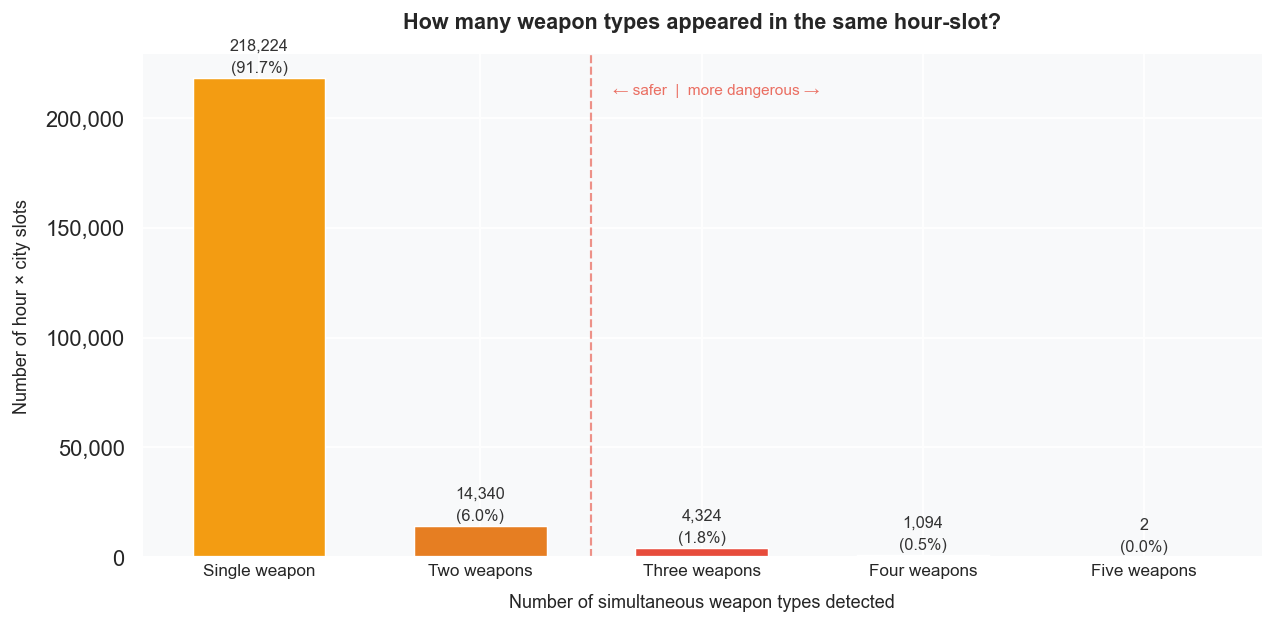

In [96]:
div_counts = hourly['tg_threat_type_count_max'].value_counts().sort_index()

COLORS = {0: '#27ae60', 1: '#f39c12', 2: '#e67e22', 3: '#e74c3c', 4: '#c0392b', 5: '#922b21', 6: '#7b241c'}
LABELS = {
    0: 'No threat',
    1: 'Single weapon',
    2: 'Two weapons',
    3: 'Three weapons',
    4: 'Four weapons',
    5: 'Five weapons',
    6: 'Six weapons',
}

colors_div = [COLORS.get(i, '#7b241c') for i in div_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

bars = ax.bar(
    [LABELS.get(i, str(i)) for i in div_counts.index],
    div_counts.values,
    color=colors_div,
    edgecolor='white',
    linewidth=0.8,
    width=0.6,
)

total = div_counts.sum()
for bar, val in zip(bars, div_counts.values):
    pct = val / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + total * 0.005,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9, linespacing=1.6, color='#333'
    )

ax.axvline(x=1.5, color='#e74c3c', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(1.6, ax.get_ylim()[1] * 0.92, '← safer  |  more dangerous →',
        fontsize=8.5, color='#e74c3c', alpha=0.8)

ax.set_title('How many weapon types appeared in the same hour-slot?',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Number of simultaneous weapon types detected', fontsize=10, labelpad=8)
ax.set_ylabel('Number of hour × city slots', fontsize=10, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', length=0, labelsize=9.5)

plt.tight_layout()
plt.show()

**The vast majority of hour×city slots contain either no threat (30.6%) or a single weapon type (61.2%)**, meaning most alerts are straightforward single-threat events.

**Combined strikes are rare but present** — two simultaneous weapon types appear in 6.3% of slots, three in 1.6%, and four or five in under 0.5% combined. These multi-weapon slots likely correspond to Russia's mass combined strikes where drones and missiles are launched simultaneously to overwhelm air defense.

**`tg_threat_type_count_max` is a meaningful feature** — even though combined strikes are rare, they represent the most dangerous scenarios and the model should be able to distinguish them from single-weapon alerts.

### 5.8 City Rankings — Total Message Exposure & Threat-Type Mix

The left chart ranks cities by total message mentions. The right shows what kinds of threats 
each city faced. 

In [ ]:
city_summary = hourly.groupby('city').agg(
    total_msgs  = ('tg_msg_count', 'sum'),
    total_hours = ('hour_slot', 'nunique'),
    shaheds     = ('tg_shaheds_count', 'sum'),
    ballistic   = ('tg_ballistic_count', 'sum'),
    cruise      = ('tg_cruise_count', 'sum'),
    guided      = ('tg_guided_bombs_count', 'sum'),
    artillery   = ('tg_artillery_count', 'sum'),
    mig31       = ('tg_mig31_count', 'sum'),
).sort_values('total_msgs', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: total messages horizontal bar
axes[0].barh(city_summary.index[::-1], city_summary['total_msgs'][::-1],
             color='steelblue', edgecolor='white')
axes[0].set_title('Total Messages per City (all years)', fontweight='bold')
axes[0].set_xlabel('Total message mentions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
for i, (city, row) in enumerate(city_summary[::-1].iterrows()):
    axes[0].text(row['total_msgs'] + 200, i, f"{row['total_msgs']:,}",
                 va='center', fontsize=8)

# Right: stacked bar of threat-type totals
threat_city = city_summary[['shaheds','ballistic','cruise','guided','artillery','mig31']].copy()
threat_city.columns = ['Shaheds/UAV','Ballistic','Cruise','Guided Bombs','Artillery','MiG-31']
threat_city = threat_city.sort_values('Shaheds/UAV', ascending=True)
bar_colors  = ['#e07b39','#c0392b','#2980b9','#27ae60','#f39c12','#8e44ad']
threat_city.plot(kind='barh', stacked=True, ax=axes[1],
                 color=bar_colors, edgecolor='white', linewidth=0.3)
axes[1].set_title('Threat-Type Mix per City (stacked totals)', fontweight='bold')
axes[1].set_xlabel('Total threat mentions')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
axes[1].legend(fontsize=8.5, loc='lower right', ncol=2)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Message volume is relatively uniform across cities**, ranging from ~8,300 (Uzhhorod) to ~17,000 (Sumy) — a much narrower spread than expected, confirming that nationwide broadcast messages dominate the dataset and dilute geographic signal.

**Absolute threat volumes follow a similar pattern**, with front-line cities (Sumy, Kharkiv, Chernihiv) leading — but the gap is modest, reinforcing that raw counts alone are a weak geographic discriminator.

**The weapon mix shows the clearest geographic differentiation.** Sumy and Kharkiv have a visibly larger artillery and guided bomb segment reflecting their front-line exposure. Donetsk stands out with a notable guided bomb bar, consistent with Russian aircraft operating within glide bomb range of the contact line. Western cities (Uzhhorod, Chernivtsi, Ivano-Frankivsk) show an almost purely Shahed + ballistic + cruise mix with no proximity weapons — exactly as expected after the proximity correction.

**Cruise missiles are present across all cities** at roughly similar proportions, consistent with their role as a long-range weapon used in nationwide strike campaigns targeting infrastructure regardless of geography.

### 5.9 Feature Correlation Matrix

Shows how strongly each feature moves together with the others. 
A value close to 1 means they rise and fall together; close to 0 means they are independent. 
For example, if ballistic and cruise missiles are highly correlated, they tend to appear in the same hours — 
which suggests Russia launches them together in combined strikes.

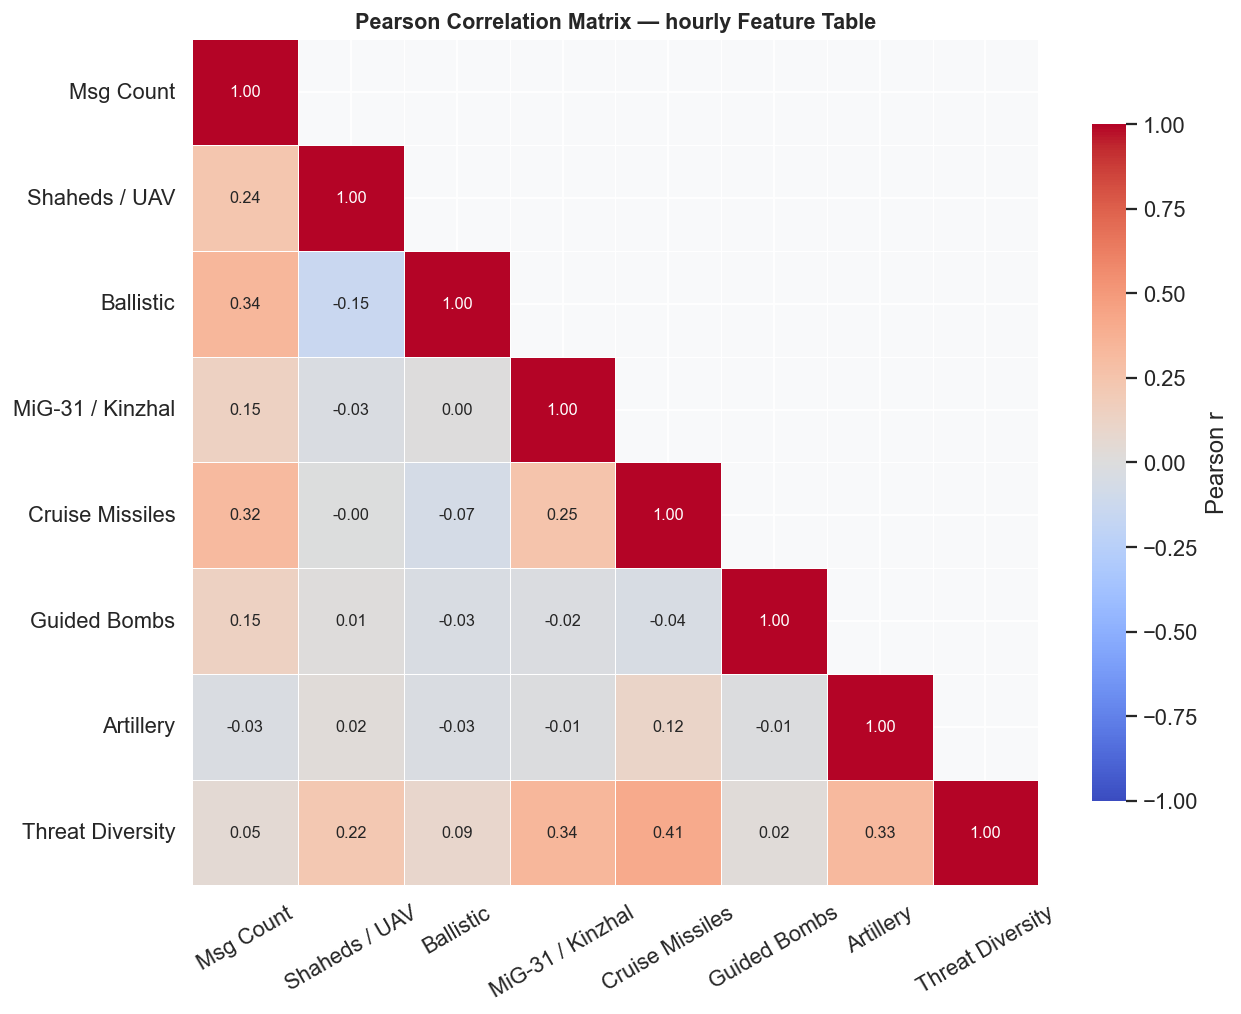

In [103]:
numeric_cols = ['tg_msg_count'] + THREAT_COLS + ['tg_threat_type_count_max']
col_labels   = ['Msg Count'] + THREAT_LABELS + ['Threat Diversity']

corr = hourly[numeric_cols].corr()
corr.index   = col_labels
corr.columns = col_labels

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title('Pearson Correlation Matrix — hourly Feature Table',
             fontweight='bold', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


**All threat features are weakly to moderately correlated with message count**, with ballistic (0.33) and cruise missiles (0.32) slightly higher than Shaheds (0.24) — suggesting missile strikes generate more reporting activity per event.

**Shaheds and ballistic missiles show a slight negative correlation (-0.16)**, which at first glance contradicts the known pattern of combined strikes. The explanation is geographic: in a combined strike, Shaheds and ballistic missiles are often reported for *different cities* — drones penetrate deep while ballistics hit specific high-value targets elsewhere. Since the feature table is structured as hour×city rows, the two weapon types end up in separate rows rather than the same one, producing an apparent anti-correlation.

**Cruise missiles correlate moderately with Kinzhal (0.25)** — both are precision long-range weapons typically used together in mass strike packages targeting infrastructure.

**Threat Diversity correlates most strongly with cruise missiles (0.45) and Shaheds (0.42)** — meaning combined multi-weapon slots are most likely to include these two types, consistent with Russia's standard combined strike doctrine of simultaneous drone and missile waves.

**Guided bombs and artillery are near-zero across the board**, confirming they are independent, geographically constrained signals with no systematic relationship to other weapon types.

### 5.11 Hour × Weekday Activity Heatmap

A 7-day by 24-hour grid showing when the channel is busiest (left) and when threats peak (right). 
Darker cells mean more activity or more threats at that hour on that day. 
This pattern can be directly encoded as a time feature in the ML model.

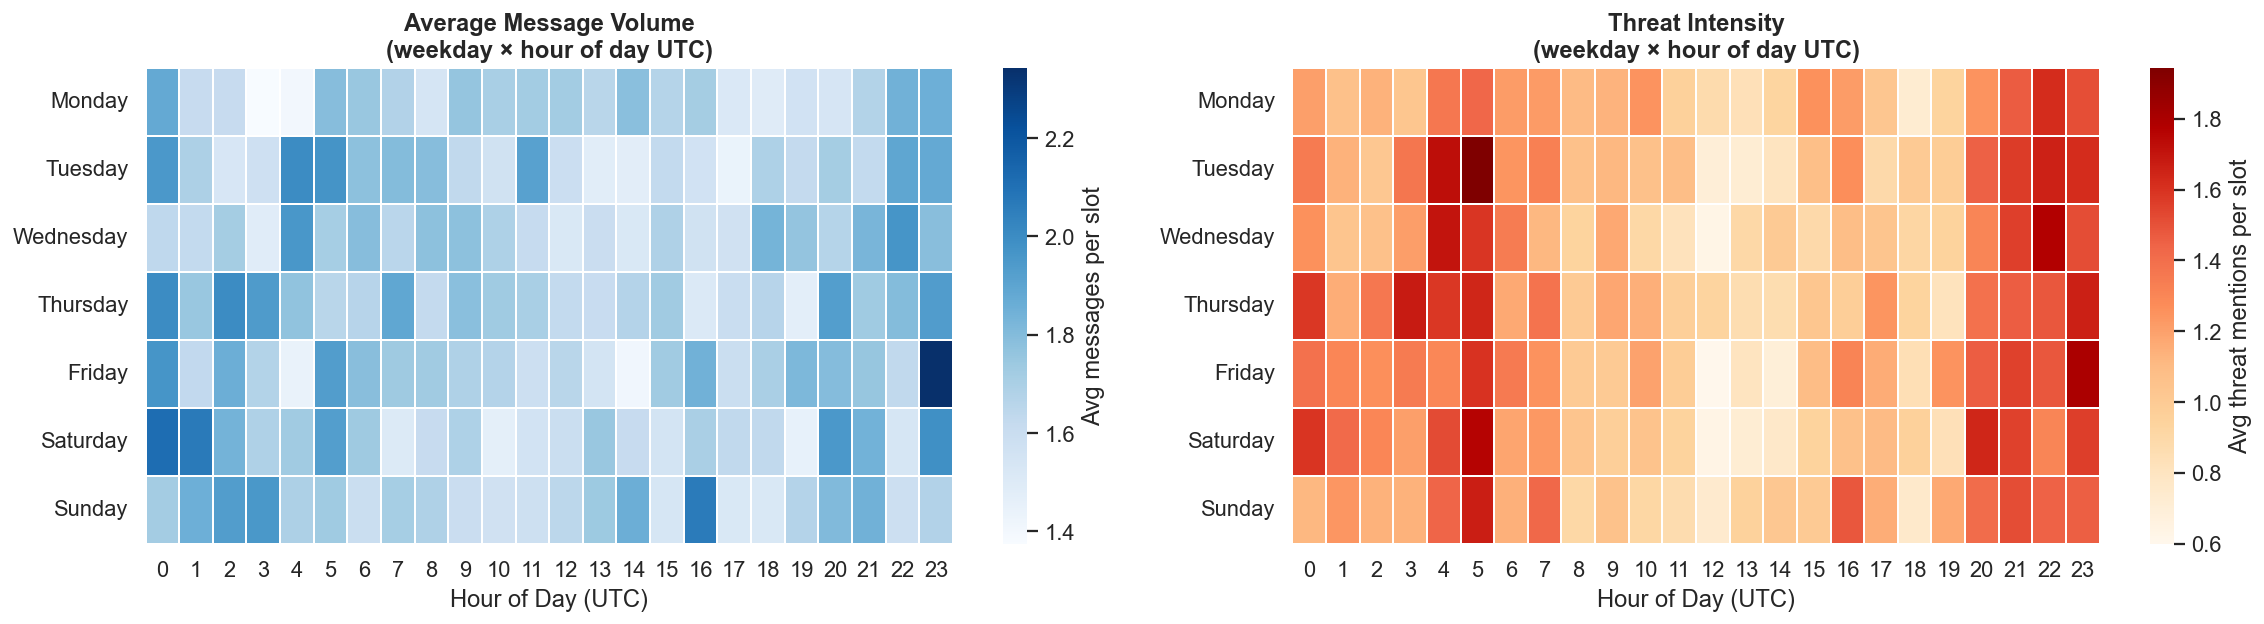

Peak threat hour (UTC): 5
Peak activity hour (UTC): 23


In [104]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Ліва карта — message volume (один проксі-город)
cp5_vol = hourly[hourly['city'] == 'Kyiv'].copy()
cp5_vol['hour']    = cp5_vol['hour_slot'].dt.hour
cp5_vol['weekday'] = cp5_vol['hour_slot'].dt.day_name()

# Права карта — реальна інтенсивність загроз (сума конкретних зброй)
cp5_vol['threat_intensity'] = (
    cp5_vol['tg_shaheds_count'] +
    cp5_vol['tg_ballistic_count'] +
    cp5_vol['tg_mig31_count'] +
    cp5_vol['tg_cruise_count'] +
    cp5_vol['tg_guided_bombs_count'] +
    cp5_vol['tg_artillery_count']
)

pivot_vol = cp5_vol.groupby(['weekday', 'hour'])['tg_msg_count'].mean().unstack().reindex(dow_order)
pivot_threat = cp5_vol.groupby(['weekday', 'hour'])['threat_intensity'].mean().unstack().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_vol, ax=axes[0], cmap='Blues', linewidths=0.1,
            cbar_kws={'label': 'Avg messages per slot'})
axes[0].set_title('Average Message Volume\n(weekday × hour of day UTC)', fontweight='bold')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('')

sns.heatmap(pivot_threat, ax=axes[1], cmap='OrRd', linewidths=0.1,
            cbar_kws={'label': 'Avg threat mentions per slot'})
axes[1].set_title('Threat Intensity\n(weekday × hour of day UTC)', fontweight='bold')
axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Peak threat hour (UTC):', pivot_threat.values.flatten().argmax() % 24)
print('Peak activity hour (UTC):', pivot_vol.values.flatten().argmax() % 24)

**Message volume and threat intensity follow opposite patterns**, confirming that high posting activity does not equal high threat activity.

**Message volume peaks around 16 UTC (18 Kyiv time)** — evening hours when the channel publishes summaries and general updates, most of which are not threat alerts.

**Threat intensity peaks at 4–6 UTC (6–8 Kyiv time)**, consistent with Russia's known preference for overnight and early morning strikes. This is when the fewest messages are posted but nearly all of them are active threat alerts.

**The two heatmaps together suggest that `tg_msg_count` and threat-specific count features carry different information** — message volume reflects channel activity rhythm, while threat counts reflect actual attack patterns. Both should be included as separate features in the model rather than using one as a proxy for the other.

**No strong day-of-week pattern is visible in either chart**, confirming that Russian strike activity does not follow a weekly schedule and the model should not treat weekday as a strong predictor.

## Saving

Since the manual spot-check confirms that keyword matching, city assignment, and hourly aggregation all produce the expected results, the dataset is ready to be saved and merged with others on `hour_slot` and `city` keys.

In [105]:
hourly.to_csv('telegram_features_hourly.csv', index=False)
print(f"Saved: {hourly.shape[0]:,} rows, {hourly.shape[1]} columns")

Saved: 237,984 rows, 12 columns
